# AI Final Project — Project 2
## Adversarial Attacks and Defenses on CIFAR-10

### Overview

Deep neural networks can achieve high accuracy on image-classification tasks, yet small and visually imperceptible perturbations may cause them to produce incorrect predictions. These modified inputs are known as **adversarial examples**.

In this notebook, several white-box adversarial attacks and defense mechanisms are implemented and evaluated on the **CIFAR-10** dataset. A **ResNet20** model is used as the image classifier.

All attacks are implemented directly with PyTorch without using automatic adversarial-attack libraries.

### Main Objectives

The notebook consists of the following stages:

1. Preparing the CIFAR-10 dataset and training a baseline ResNet20 model.
2. Implementing and evaluating four adversarial attacks:
   - Fast Gradient Sign Method (**FGSM**)
   - Projected Gradient Descent (**PGD**)
   - **DeepFool**
   - Carlini and Wagner $L_2$ attack (**C&W**)
3. Implementing and evaluating three defense mechanisms:
   - **Adversarial Training**
   - **Randomized Smoothing**
   - **Diffusion Purification**
4. Comparing the clean and robust accuracy of the resulting models.
5. Visualizing successful adversarial examples, perturbations, and final evaluation results.

### Important Implementation Detail

Adversarial perturbations are generated directly in the raw pixel space:

$$
x \in [0,1]
$$

The CIFAR-10 normalization operation is therefore placed inside the model using a dedicated `Normalize` layer. This ensures that attack budgets such as

$$
\epsilon = \frac{8}{255}
$$

retain their intended meaning in the original image space.

## Environment and Project Paths

This section configures the notebook for either local execution or Google Colab.

When `RUN_ON_DRIVE=True`, project files, datasets, checkpoints, results, and downloaded models are stored in Google Drive. Otherwise, the same directory structure is created locally.

The main directories are:

- `data`: datasets
- `checkpoints`: saved model weights
- `results`: experiment outputs
- `cache`: downloaded PyTorch and Hugging Face files

In [1]:
from pathlib import Path
import os

RUN_ON_DRIVE = False

PROJECT_NAME = "adversarial_attacks_and_defenses"


In [2]:
if RUN_ON_DRIVE:
    try:
        from google.colab import drive
    except ImportError as exc:
        raise RuntimeError(
            "RUN_ON_DRIVE=True requires Google Colab. "
            "Set RUN_ON_DRIVE=False for local execution."
        ) from exc

    DRIVE_MOUNT_DIR = Path("/content/drive")
    drive.mount(str(DRIVE_MOUNT_DIR), force_remount=False)
    PROJECT_DIR = DRIVE_MOUNT_DIR / "MyDrive" / PROJECT_NAME
else:
    current_dir = Path.cwd().resolve()
    PROJECT_DIR = (
        current_dir
        if current_dir.name == PROJECT_NAME
        else current_dir / PROJECT_NAME
    )

PROJECT_DIR = PROJECT_DIR.resolve()

DATA_DIR = PROJECT_DIR / "data"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"
RESULTS_DIR = PROJECT_DIR / "results"
CACHE_DIR = PROJECT_DIR / "cache"
HF_HOME_DIR = CACHE_DIR / "huggingface"
TORCH_HOME_DIR = CACHE_DIR / "torch"

for directory in (
    PROJECT_DIR,
    DATA_DIR,
    CHECKPOINTS_DIR,
    RESULTS_DIR,
    HF_HOME_DIR,
    TORCH_HOME_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_HOME_DIR)
os.environ["HF_HUB_CACHE"] = str(HF_HOME_DIR / "hub")
os.environ["TORCH_HOME"] = str(TORCH_HOME_DIR)

print(f"RUN_ON_DRIVE  : {RUN_ON_DRIVE}")
print(f"PROJECT_DIR   : {PROJECT_DIR}")
print(f"DATA_DIR      : {DATA_DIR}")
print(f"CHECKPOINTS   : {CHECKPOINTS_DIR}")
print(f"RESULTS_DIR   : {RESULTS_DIR}")
print(f"HF_HOME       : {os.environ['HF_HOME']}")


RUN_ON_DRIVE  : False
PROJECT_DIR   : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses
DATA_DIR      : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/data
CHECKPOINTS   : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/checkpoints
RESULTS_DIR   : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/results
HF_HOME       : /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/cache/huggingface


## Imports and Reproducibility

This section imports the required libraries, installs missing dependencies, and configures the experiment.

A fixed random seed is used for Python, NumPy, and PyTorch to make the results more reproducible. The available processing device is then selected automatically, preferring CUDA when a GPU is available.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random

In [4]:
import importlib.util
import subprocess
import sys

required_packages = {
    "diffusers": "diffusers",
    "accelerate": "accelerate"
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {package_name}...")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name
        ])

from diffusers import DDPMPipeline

print("Diffusers dependencies are ready.")

/home/ali/Desktop/projects/QAI/.qai_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Diffusers dependencies are ready.


In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [6]:
RANDOM_SEED = 42
set_seed(RANDOM_SEED)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
BATCH_SIZE = 128
NUM_WORKERS = 2

## CIFAR-10 Data Preparation

The dataset is split into training, validation, and test sets. Images remain in the pixel range $[0,1]$ so adversarial perturbations can be applied with the correct scale.

In [9]:
DATA_ROOT = DATA_DIR / "cifar10"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

VAL_SIZE = 5000

PIN_MEMORY = torch.cuda.is_available()

print("CIFAR-10 root:", DATA_ROOT)


CIFAR-10 root: /home/ali/Desktop/AUT/AI/adversarial_attacks_and_defenses/data/cifar10


In [10]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

raw_transform = transforms.Compose([
    transforms.ToTensor()
])

In [11]:
full_train_aug_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=train_transform
)

full_train_raw_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=raw_transform
)


test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=raw_transform
)


CIFAR10_CLASSES = full_train_raw_dataset.classes

print("Classes:", CIFAR10_CLASSES)
print("Full train size:", len(full_train_raw_dataset))
print("Test size:", len(test_dataset))

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Full train size: 50000
Test size: 10000


In [12]:
num_train = len(full_train_raw_dataset)
indices = torch.randperm(num_train, generator=torch.Generator().manual_seed(RANDOM_SEED))

val_indices = indices[:VAL_SIZE]
train_indices = indices[VAL_SIZE:]

In [13]:
train_dataset = torch.utils.data.Subset(full_train_aug_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_train_raw_dataset, val_indices)
mean_std_dataset = torch.utils.data.Subset(full_train_raw_dataset, train_indices)

In [14]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [15]:
mean_std_loader = torch.utils.data.DataLoader(
    mean_std_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [16]:
# Sanity Check
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())
print("First labels:", labels[:10])

Images shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])
Min pixel value: 0.0
Max pixel value: 1.0
First labels: tensor([7, 4, 0, 1, 8, 1, 7, 6, 5, 5])


## Baseline Model

A ResNet20 classifier is used as the baseline model. The normalization layer is placed inside the model so that its input remains in the range $[0,1]$.

$$
x_{\text{norm}} = \frac{x-\mu}{\sigma}
$$

In [17]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        mean = torch.tensor(mean).view(1, 3, 1, 1)
        std = torch.tensor(std).view(1, 3, 1, 1)
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / self.std

In [18]:
def compute_mean_std(loader):
    channels_sum = torch.zeros(3)
    channels_squared_sum = torch.zeros(3)
    num_pixels = 0

    for images, _ in loader:
        batch_size, channels, height, width = images.shape

        num_pixels += batch_size * height * width

        channels_sum += images.sum(dim=[0, 2, 3])
        channels_squared_sum += (images ** 2).sum(dim=[0, 2, 3])

    mean = channels_sum / num_pixels

    std = torch.sqrt(channels_squared_sum / num_pixels - mean ** 2)

    return mean, std

In [19]:
cifar10_mean, cifar10_std = compute_mean_std(mean_std_loader)

cifar10_mean = cifar10_mean.tolist()
cifar10_std = cifar10_std.tolist()

print("Mean:", cifar10_mean)
print("Std:", cifar10_std)

Mean: [0.4913501441478729, 0.4821614623069763, 0.44659730792045593]
Std: [0.24704869091510773, 0.24355383217334747, 0.26168447732925415]


In [20]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + self.shortcut(x)
        out = F.relu(out)

        return out

In [21]:
class ResNet20(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 16

        self.conv1 = nn.Conv2d(
            3,
            16,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(16)

        self.layer1 = self._make_layer(
            out_channels=16,
            num_blocks=3,
            stride=1
        )

        self.layer2 = self._make_layer(
            out_channels=32,
            num_blocks=3,
            stride=2
        )

        self.layer3 = self._make_layer(
            out_channels=64,
            num_blocks=3,
            stride=2
        )

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

        self._initialize_weights()

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []

        layers.append(
            BasicBlock(
                in_channels=self.in_channels,
                out_channels=out_channels,
                stride=stride
            )
        )

        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(
                BasicBlock(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)

        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        return out

In [22]:
def build_resnet20_model(cifar10_mean, cifar10_std, device, num_classes=10):
    resnet20 = ResNet20(num_classes=num_classes)

    model = nn.Sequential(
        Normalize(cifar10_mean, cifar10_std),
        resnet20
    ).to(device)

    return model

In [23]:
model = build_resnet20_model(cifar10_mean, cifar10_std, device, 10)
model

Sequential(
  (0): Normalize()
  (1): ResNet20(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=

In [24]:
# Sanity Check
x_dummy = torch.rand(4, 3, 32, 32).to(device)

with torch.no_grad():
    logits = model(x_dummy)

print("Output shape:", logits.shape) # Should be [4, 10]

Output shape: torch.Size([4, 10])


## Baseline Model Training

The ResNet20 model is trained using cross-entropy loss and SGD. The best checkpoint is selected based on validation accuracy.

In [25]:
EPOCHS = 30
LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

SAVE_PATH = CHECKPOINTS_DIR / "resnet20_cifar10_clean.pth"


In [26]:
saved_model_exists = False

In [27]:
if SAVE_PATH.exists():
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    model = model.to(device)
    model.eval()

    saved_model_exists = True

    print(f"Loaded saved model from: {SAVE_PATH}")
else:
    print("No saved model found. Training from scratch.")


No saved model found. Training from scratch.


In [28]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [29]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)


        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [30]:
if not saved_model_exists:
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[15, 25],
        gamma=0.1
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = -float("inf")

    for epoch in range(EPOCHS):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device
        )

        val_loss, val_acc = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), SAVE_PATH)

        elapsed = time.time() - start_time

        print(
            f"Epoch [{epoch + 1:02d}/{EPOCHS}] "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} "
            f"val_acc={val_acc:.4f} "
            f"lr={scheduler.get_last_lr()[0]:.5f} "
            f"time={elapsed:.1f}s"
        )

    print("Best validation accuracy:", best_val_acc)
    print("Saved model:", SAVE_PATH)
else:
    print("Skipping training because saved model already exists.")

Epoch [01/30] train_loss=1.6886 train_acc=0.3605 val_loss=1.4343 val_acc=0.4758 lr=0.10000 time=23.0s
Epoch [02/30] train_loss=1.1754 train_acc=0.5716 val_loss=1.1136 val_acc=0.6038 lr=0.10000 time=22.7s
Epoch [03/30] train_loss=0.9490 train_acc=0.6622 val_loss=1.1281 val_acc=0.6348 lr=0.10000 time=23.2s
Epoch [04/30] train_loss=0.8124 train_acc=0.7141 val_loss=0.8036 val_acc=0.7202 lr=0.10000 time=22.9s
Epoch [05/30] train_loss=0.7362 train_acc=0.7442 val_loss=0.9146 val_acc=0.6886 lr=0.10000 time=22.5s
Epoch [06/30] train_loss=0.6864 train_acc=0.7617 val_loss=1.1825 val_acc=0.6462 lr=0.10000 time=22.5s
Epoch [07/30] train_loss=0.6483 train_acc=0.7766 val_loss=0.6980 val_acc=0.7676 lr=0.10000 time=22.5s
Epoch [08/30] train_loss=0.6153 train_acc=0.7881 val_loss=1.2731 val_acc=0.6426 lr=0.10000 time=22.5s
Epoch [09/30] train_loss=0.5987 train_acc=0.7935 val_loss=0.8713 val_acc=0.7196 lr=0.10000 time=22.5s
Epoch [10/30] train_loss=0.5905 train_acc=0.7968 val_loss=0.8863 val_acc=0.7254 lr

In [31]:
if not saved_model_exists:
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    model = model.to(device)
    model.eval()
    print("Loaded best validation model.")

Loaded best validation model.


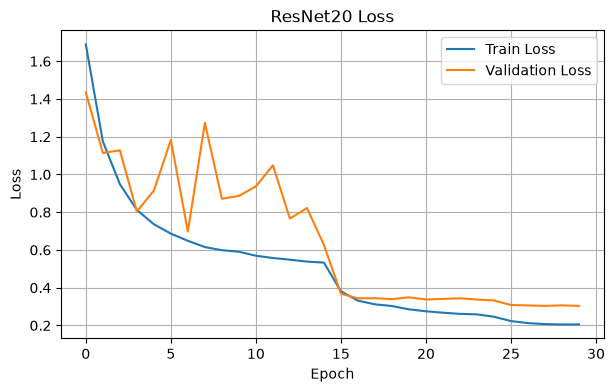

In [32]:
if not saved_model_exists:
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("ResNet20 Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

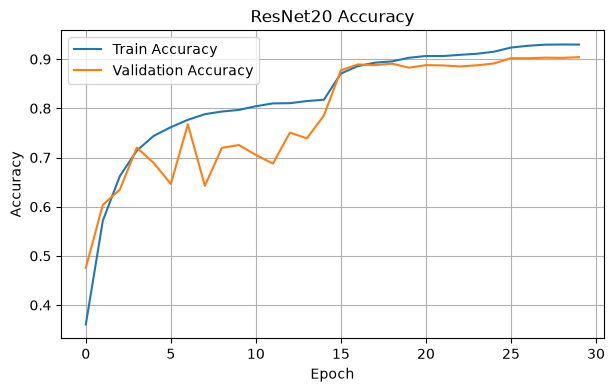

In [33]:
if not saved_model_exists:
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("ResNet20 Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [34]:
criterion = nn.CrossEntropyLoss()

val_loss, val_acc = evaluate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device
)

test_loss, test_acc = evaluate(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Validation accuracy: 0.9040
Test accuracy: 0.8912


## FGSM Attack

FGSM creates an adversarial image using one step in the direction of the input gradient:

$$
x_{\text{adv}} =
\operatorname{clip}_{[0,1]}
\left(
x+\epsilon\,\operatorname{sign}
\left(\nabla_x L(\theta,x,y)\right)
\right)
$$

In [35]:
FGSM_EPSILONS = [0.0, 2 / 255, 4 / 255, 8 / 255, 16 / 255]

In [36]:
def fgsm_attack(model, images, labels, epsilon, criterion, device):
    model.eval()

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    images.requires_grad = True

    logits = model(images)
    loss = criterion(logits, labels)

    model.zero_grad()
    loss.backward()

    grad_sign = images.grad.sign()

    adv_images = images + epsilon * grad_sign
    adv_images = torch.clamp(adv_images, 0.0, 1.0)

    return adv_images.detach()

In [37]:
# Sanity Check
sanity_check_images, sanity_check_labels = next(iter(test_loader))

sanity_check_images = sanity_check_images.to(device)
sanity_check_labels = sanity_check_labels.to(device)

tolerance = 1e-6

for sanity_check_eps in FGSM_EPSILONS:

    sanity_check_adv_images = fgsm_attack(
        model,
        sanity_check_images,
        sanity_check_labels,
        sanity_check_eps,
        criterion,
        device
    )

    delta = sanity_check_adv_images - sanity_check_images

    assert delta.abs().max().item() <= sanity_check_eps + tolerance

In [38]:
def evaluate_fgsm(model, loader, epsilons, criterion, device):
    results = {}

    for epsilon in epsilons:
        total_correct = 0
        total_samples = 0

        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if epsilon == 0.0:
                adv_images = images
            else:
                adv_images = fgsm_attack(
                    model,
                    images,
                    labels,
                    epsilon,
                    criterion,
                    device
                )

            with torch.no_grad():
                logits = model(adv_images)
                preds = logits.argmax(dim=1)

            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        accuracy = total_correct / total_samples
        results[epsilon] = accuracy

        print(f"epsilon={epsilon:.5f} | accuracy={accuracy:.4f}")

    return results

In [39]:
criterion = nn.CrossEntropyLoss()

fgsm_results = evaluate_fgsm(
    model,
    test_loader,
    FGSM_EPSILONS,
    criterion,
    device
)

epsilon=0.00000 | accuracy=0.8912
epsilon=0.00784 | accuracy=0.2158
epsilon=0.01569 | accuracy=0.1149
epsilon=0.03137 | accuracy=0.0787
epsilon=0.06275 | accuracy=0.0713


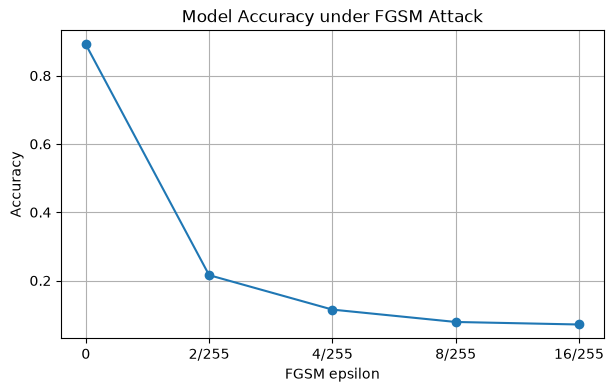

In [40]:
eps_labels = ["0", "2/255", "4/255", "8/255", "16/255"]
accuracies = [fgsm_results[eps] for eps in FGSM_EPSILONS]

plt.figure(figsize=(7, 4))
plt.plot(eps_labels, accuracies, marker="o")
plt.xlabel("FGSM epsilon")
plt.ylabel("Accuracy")
plt.title("Model Accuracy under FGSM Attack")
plt.grid(True)
plt.show()

In [41]:
def get_confidence_and_pred(model, image):
    model.eval()

    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1)

        confidence, pred = probs.max(dim=1)

    return confidence.item(), pred.item()

In [42]:
def find_correct_sample(model, loader, device, idx=0):
    model.eval()

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            logits = model(images)
            preds = logits.argmax(dim=1)

        correct_indices = (preds == labels).nonzero(as_tuple=True)[0]

        if len(correct_indices) > 0:
            if idx >= len(correct_indices):
                idx = 0

            sample_idx = correct_indices[idx].item()
            return images[sample_idx].detach().cpu(), labels[sample_idx].detach().cpu()

    raise RuntimeError("No correctly classified sample found.")

In [43]:
def find_fgsm_successful_examples(
    model,
    loader,
    epsilon,
    criterion,
    device,
    num_examples=2
):
    model.eval()

    successful_examples = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.no_grad():
            clean_logits = model(images)
            clean_probs = F.softmax(clean_logits, dim=1)
            clean_confidences, clean_preds = clean_probs.max(dim=1)

        initially_correct_mask = clean_preds == labels

        if not initially_correct_mask.any():
            continue

        clean_images = images[initially_correct_mask]
        clean_labels = labels[initially_correct_mask]
        clean_preds = clean_preds[initially_correct_mask]
        clean_confidences = clean_confidences[initially_correct_mask]

        adv_images = fgsm_attack(
            model=model,
            images=clean_images,
            labels=clean_labels,
            epsilon=epsilon,
            criterion=criterion,
            device=device
        )

        with torch.no_grad():
            adv_logits = model(adv_images)
            adv_probs = F.softmax(adv_logits, dim=1)
            adv_confidences, adv_preds = adv_probs.max(dim=1)

        successful_indices = (
            adv_preds != clean_labels
        ).nonzero(as_tuple=True)[0]

        for sample_idx in successful_indices:
            successful_examples.append({
                "clean_image": clean_images[sample_idx].detach().cpu(),
                "adv_image": adv_images[sample_idx].detach().cpu(),
                "label": clean_labels[sample_idx].item(),
                "clean_pred": clean_preds[sample_idx].item(),
                "clean_confidence": clean_confidences[sample_idx].item(),
                "adv_pred": adv_preds[sample_idx].item(),
                "adv_confidence": adv_confidences[sample_idx].item()
            })

            if len(successful_examples) == num_examples:
                return successful_examples

    raise RuntimeError(
        f"Only {len(successful_examples)} successful FGSM examples "
        f"were found, but {num_examples} were requested."
    )

In [44]:
def show_fgsm_examples_for_eps_values(
    model,
    loader,
    epsilons,
    criterion,
    class_names,
    device,
    idx=0
):
    positive_epsilons = [
        epsilon
        for epsilon in epsilons
        if epsilon > 0.0
    ]

    if not positive_epsilons:
        raise ValueError(
            "At least one non-zero epsilon is required "
            "to find a successful FGSM example."
        )

    reference_epsilon = max(positive_epsilons)

    successful_examples = find_fgsm_successful_examples(
        model=model,
        loader=loader,
        epsilon=reference_epsilon,
        criterion=criterion,
        device=device,
        num_examples=idx + 1
    )

    selected_example = successful_examples[idx]

    clean_image = selected_example["clean_image"]
    true_label = selected_example["label"]

    images_to_show = []
    titles = []

    for epsilon in epsilons:
        if epsilon == 0.0:
            display_image = clean_image.clone()

        else:
            adv_image = fgsm_attack(
                model=model,
                images=clean_image.unsqueeze(0).to(device),
                labels=torch.tensor(
                    [true_label],
                    dtype=torch.long,
                    device=device
                ),
                epsilon=epsilon,
                criterion=criterion,
                device=device
            )

            display_image = (
                adv_image
                .squeeze(0)
                .detach()
                .cpu()
            )

        confidence, pred = get_confidence_and_pred(
            model,
            display_image
        )

        images_to_show.append(display_image)

        if epsilon == 0.0:
            eps_text = "Clean"
        else:
            eps_text = f"eps={epsilon:.4f}"

        title = (
            f"{eps_text}\n"
            f"Pred: {class_names[pred]}\n"
            f"Conf: {confidence:.2f}"
        )

        titles.append(title)

    plt.figure(figsize=(15, 3))

    for i, image in enumerate(images_to_show):
        plt.subplot(1, len(images_to_show), i + 1)

        image_np = image.permute(1, 2, 0).numpy()
        image_np = np.clip(image_np, 0.0, 1.0)

        plt.imshow(image_np)
        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle(
        (
            f"True Label: {class_names[true_label]}"
            f"\nSelected using successful FGSM at "
            f"eps={reference_epsilon:.4f}"
        ),
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

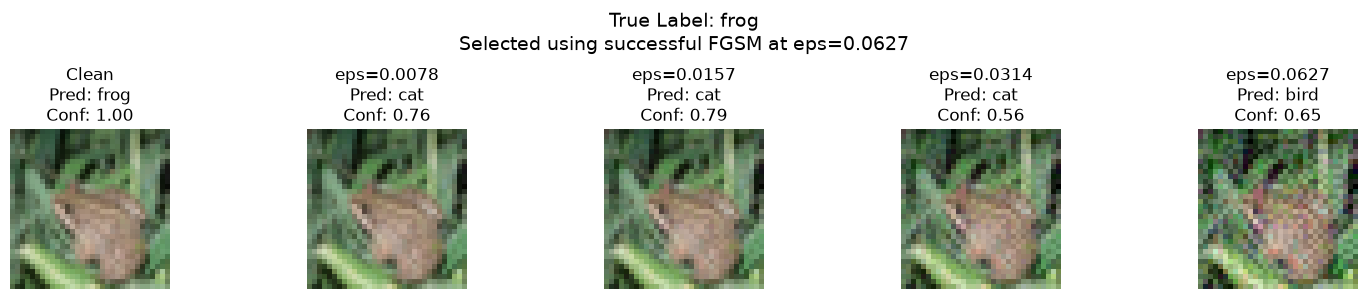

In [45]:
show_fgsm_examples_for_eps_values(
    model=model,
    loader=test_loader,
    epsilons=FGSM_EPSILONS,
    criterion=criterion,
    class_names=CIFAR10_CLASSES,
    device=device,
    idx=4
)

In [46]:
def show_fgsm_successful_examples(
    model,
    loader,
    epsilon,
    criterion,
    class_names,
    device,
    num_examples=2
):
    examples = find_fgsm_successful_examples(
        model=model,
        loader=loader,
        epsilon=epsilon,
        criterion=criterion,
        device=device,
        num_examples=num_examples
    )

    fig, axes = plt.subplots(
        num_examples,
        3,
        figsize=(10, 3.5 * num_examples)
    )

    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, example in enumerate(examples):
        clean_image = example["clean_image"]
        adv_image = example["adv_image"]

        noise = adv_image - clean_image

        if epsilon > 0:
            noise_for_display = noise / (2 * epsilon) + 0.5
        else:
            noise_for_display = torch.full_like(noise, 0.5)

        noise_for_display = torch.clamp(
            noise_for_display,
            0.0,
            1.0
        )

        l_inf = noise.abs().max().item()
        l2_norm = torch.norm(
            noise.flatten(),
            p=2
        ).item()

        images_to_show = [
            clean_image,
            noise_for_display,
            adv_image
        ]

        titles = [
            (
                "Clean\n"
                f"True: {class_names[example['label']]}\n"
                f"Pred: {class_names[example['clean_pred']]}\n"
                f"Confidence: {example['clean_confidence']:.3f}"
            ),
            (
                "FGSM Perturbation\n"
                "Scaled for display\n"
                f"L∞: {l_inf:.5f}\n"
                f"L2: {l2_norm:.4f}"
            ),
            (
                "Adversarial\n"
                f"Pred: {class_names[example['adv_pred']]}\n"
                f"Confidence: {example['adv_confidence']:.3f}"
            )
        ]

        for col, image in enumerate(images_to_show):
            image_np = image.permute(1, 2, 0).numpy()
            image_np = np.clip(image_np, 0.0, 1.0)

            axes[row, col].imshow(image_np)
            axes[row, col].set_title(titles[col])
            axes[row, col].axis("off")

    fig.suptitle(
        f"Successful FGSM Examples — ε = {epsilon:.5f}",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

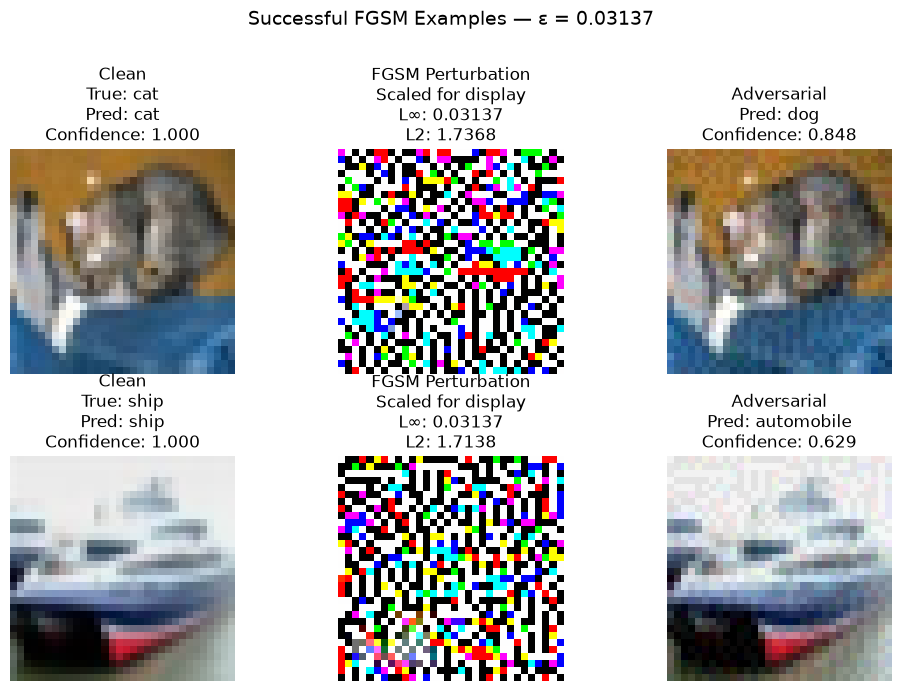

In [47]:
show_fgsm_successful_examples(
    model=model,
    loader=test_loader,
    epsilon=8 / 255,
    criterion=criterion,
    class_names=CIFAR10_CLASSES,
    device=device,
    num_examples=2
)

## PGD Attack

PGD repeatedly applies small FGSM steps and projects the result back into the allowed perturbation region:

$$
x^{t+1} =
\Pi_{x + B_\epsilon}
\left(
x^t+\alpha\,\operatorname{sign}
\left(\nabla_{x^t}L(\theta,x^t,y)\right)
\right)
$$

In [48]:
PGD_EPSILON = 8 / 255
PGD_ALPHA = 2 / 255
PGD_STEPS = 20
PGD_RANDOM_START = True

In [49]:
def pgd_attack(model, images, labels, epsilon, alpha, num_steps, criterion, device, random_start=True):
    model.eval()

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    if random_start:
        delta = torch.empty_like(images).uniform_(-epsilon, epsilon)
        adv_images = images + delta
        adv_images = torch.clamp(adv_images, 0.0, 1.0)
    else:
        adv_images = images.clone().detach()

    for _ in range(num_steps):
        adv_images.requires_grad = True

        logits = model(adv_images)
        loss = criterion(logits, labels)

        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            grad_sign = adv_images.grad.sign()

            adv_images = adv_images + alpha * grad_sign

            delta = adv_images - images
            delta = torch.clamp(delta, -epsilon, epsilon)

            adv_images = images + delta
            adv_images = torch.clamp(adv_images, 0.0, 1.0)

        adv_images = adv_images.detach()

    return adv_images

In [50]:
# Sanity Check
sanity_check_images, sanity_check_labels = next(iter(test_loader))

sanity_check_images = sanity_check_images.to(device)
sanity_check_labels = sanity_check_labels.to(device)

sanity_check_adv_images = pgd_attack(
    model,
    sanity_check_images,
    sanity_check_labels,
    PGD_EPSILON,
    PGD_ALPHA,
    PGD_STEPS,
    criterion,
    device,
    random_start=PGD_RANDOM_START
)

delta = sanity_check_adv_images - sanity_check_images
max_delta = delta.abs().max().item()

print("Max |delta|:", max_delta)
print("Epsilon:", PGD_EPSILON)
print("Difference:", max_delta - PGD_EPSILON)
print("Adv min:", sanity_check_adv_images.min().item())
print("Adv max:", sanity_check_adv_images.max().item())

assert max_delta <= PGD_EPSILON + 1e-6
assert sanity_check_adv_images.min().item() >= 0.0
assert sanity_check_adv_images.max().item() <= 1.0

Max |delta|: 0.03137257695198059
Epsilon: 0.03137254901960784
Difference: 2.793237274811844e-08
Adv min: 0.0
Adv max: 1.0


In [51]:
def evaluate_pgd(model, loader, epsilon, alpha, num_steps, criterion, device, random_start=True):
    model.eval()

    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        adv_images = pgd_attack(
            model,
            images,
            labels,
            epsilon,
            alpha,
            num_steps,
            criterion,
            device,
            random_start
        )

        with torch.no_grad():
            logits = model(adv_images)
            preds = logits.argmax(dim=1)

        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    accuracy = total_correct / total_samples

    print(
        f"PGD accuracy | "
        f"epsilon={epsilon:.5f}, "
        f"alpha={alpha:.5f}, "
        f"steps={num_steps}: "
        f"{accuracy:.4f}"
    )

    return accuracy

In [52]:
pgd_acc = evaluate_pgd(
    model,
    test_loader,
    PGD_EPSILON,
    PGD_ALPHA,
    PGD_STEPS,
    criterion,
    device,
    PGD_RANDOM_START
)

PGD accuracy | epsilon=0.03137, alpha=0.00784, steps=20: 0.0000


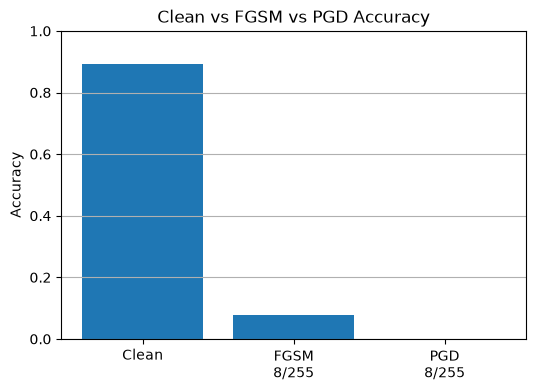

In [53]:
clean_acc = fgsm_results[0.0]
fgsm_acc_8_255 = fgsm_results[8 / 255]

attack_names = ["Clean", "FGSM\n8/255", "PGD\n8/255"]
attack_accuracies = [clean_acc, fgsm_acc_8_255, pgd_acc]

plt.figure(figsize=(6, 4))
plt.bar(attack_names, attack_accuracies)
plt.ylabel("Accuracy")
plt.title("Clean vs FGSM vs PGD Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

In [54]:
def find_pgd_successful_examples(
    model,
    loader,
    epsilon,
    alpha,
    num_steps,
    criterion,
    device,
    random_start=True,
    num_examples=2
):
    model.eval()

    successful_examples = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.no_grad():
            clean_logits = model(images)
            clean_probs = F.softmax(clean_logits, dim=1)
            clean_confidences, clean_preds = clean_probs.max(dim=1)

        correct_mask = clean_preds == labels

        if not correct_mask.any():
            continue

        clean_images = images[correct_mask]
        clean_labels = labels[correct_mask]
        clean_preds = clean_preds[correct_mask]
        clean_confidences = clean_confidences[correct_mask]

        adv_images = pgd_attack(
            model=model,
            images=clean_images,
            labels=clean_labels,
            epsilon=epsilon,
            alpha=alpha,
            num_steps=num_steps,
            criterion=criterion,
            device=device,
            random_start=random_start
        )

        with torch.no_grad():
            adv_logits = model(adv_images)
            adv_probs = F.softmax(adv_logits, dim=1)
            adv_confidences, adv_preds = adv_probs.max(dim=1)

        successful_indices = (
            adv_preds != clean_labels
        ).nonzero(as_tuple=True)[0]

        for sample_idx in successful_indices:
            successful_examples.append({
                "clean_image": (
                    clean_images[sample_idx]
                    .detach()
                    .cpu()
                ),
                "adv_image": (
                    adv_images[sample_idx]
                    .detach()
                    .cpu()
                ),
                "label": clean_labels[sample_idx].item(),
                "clean_pred": clean_preds[sample_idx].item(),
                "clean_confidence": clean_confidences[sample_idx].item(),
                "adv_pred": adv_preds[sample_idx].item(),
                "adv_confidence": adv_confidences[sample_idx].item()
            })

            if len(successful_examples) >= num_examples:
                return successful_examples

    raise RuntimeError(
        f"Only {len(successful_examples)} successful PGD examples "
        f"were found, but {num_examples} were requested."
    )

In [55]:
def show_pgd_successful_example(
    model,
    loader,
    epsilon,
    alpha,
    num_steps,
    criterion,
    class_names,
    device,
    random_start=True,
    num_examples=2
):
    examples = find_pgd_successful_examples(
        model=model,
        loader=loader,
        epsilon=epsilon,
        alpha=alpha,
        num_steps=num_steps,
        criterion=criterion,
        device=device,
        random_start=random_start,
        num_examples=num_examples
    )

    fig, axes = plt.subplots(
        num_examples,
        3,
        figsize=(10, 3.5 * num_examples)
    )

    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, example in enumerate(examples):
        clean_image = example["clean_image"]
        adv_image = example["adv_image"]

        perturbation = adv_image - clean_image

        if epsilon > 0:
            perturbation_display = (
                perturbation / (2 * epsilon)
            ) + 0.5
        else:
            perturbation_display = torch.full_like(
                perturbation,
                0.5
            )

        perturbation_display = torch.clamp(
            perturbation_display,
            0.0,
            1.0
        )

        l_inf = perturbation.abs().max().item()
        l2_norm = torch.norm(
            perturbation.flatten(),
            p=2
        ).item()

        images_to_show = [
            clean_image,
            perturbation_display,
            adv_image
        ]

        titles = [
            (
                "Clean\n"
                f"Pred: {class_names[example['clean_pred']]}\n"
                f"Conf: {example['clean_confidence']:.2f}"
            ),
            (
                "PGD Perturbation\n"
                "Scaled for display\n"
                f"L∞: {l_inf:.5f}\n"
                f"L2: {l2_norm:.4f}"
            ),
            (
                "Adversarial\n"
                f"Pred: {class_names[example['adv_pred']]}\n"
                f"Conf: {example['adv_confidence']:.2f}"
            )
        ]

        for col, image in enumerate(images_to_show):
            image_np = (
                image
                .permute(1, 2, 0)
                .numpy()
            )

            image_np = np.clip(
                image_np,
                0.0,
                1.0
            )

            axes[row, col].imshow(image_np)
            axes[row, col].set_title(titles[col])
            axes[row, col].axis("off")

        axes[row, 0].set_ylabel(
            (
                f"True: {class_names[example['label']]}\n"
                f"Example {row + 1}"
            ),
            fontsize=11
        )

    fig.suptitle(
        (
            f"Successful PGD Examples\n"
            f"ε={epsilon:.5f}, "
            f"α={alpha:.5f}, "
            f"steps={num_steps}"
        ),
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

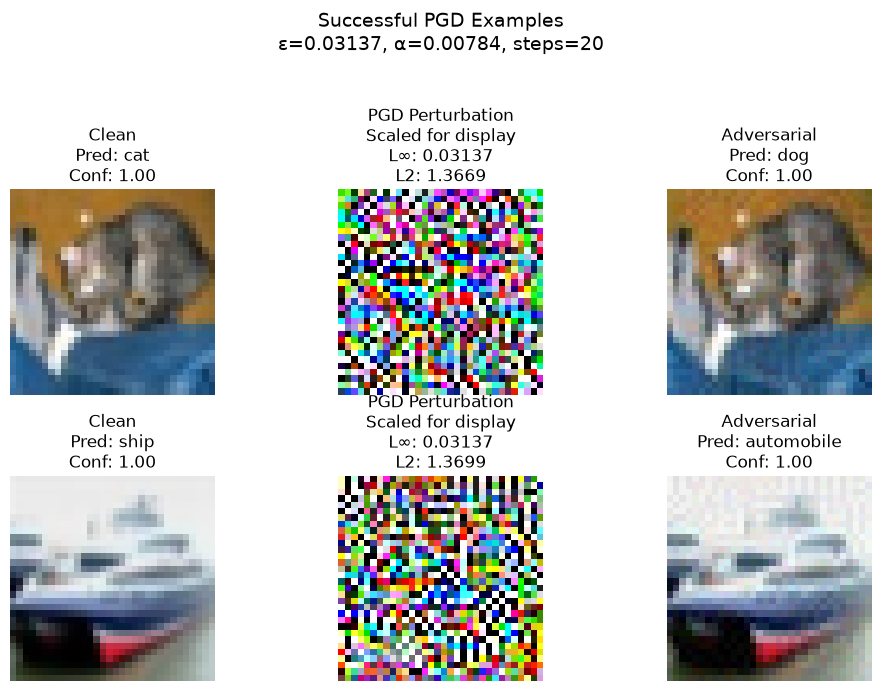

In [56]:
show_pgd_successful_example(
    model=model,
    loader=test_loader,
    epsilon=PGD_EPSILON,
    alpha=PGD_ALPHA,
    num_steps=PGD_STEPS,
    criterion=criterion,
    class_names=CIFAR10_CLASSES,
    device=device,
    random_start=PGD_RANDOM_START,
    num_examples=2
)

In [57]:
PGD_EPSILONS = [0.0, 2 / 255, 4 / 255, 8 / 255, 16 / 255]

In [58]:
def evaluate_pgd_multiple_eps(
    model,
    loader,
    epsilons,
    num_steps,
    criterion,
    device,
    random_start=True
):
    model.eval()

    results = {}

    for epsilon in epsilons:
        total_correct = 0
        total_samples = 0

        if epsilon == 0.0:
            alpha = 0
        else:
            alpha = epsilon / 4

        for images,labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if epsilon == 0.0:
                adv_images = images
            else:
                adv_images = pgd_attack(
                    model,
                    images,
                    labels,
                    epsilon,
                    alpha,
                    num_steps,
                    criterion,
                    device,
                    random_start=random_start
                )

            with torch.no_grad():
                logits = model(adv_images)
                preds = logits.argmax(dim=1)

            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        accuracy = total_correct / total_samples

        results[epsilon] = accuracy


        print(
            f"epsilon={epsilon:.5f} | "
            f"alpha={alpha:.5f} | "
            f"steps={num_steps} | "
            f"accuracy={accuracy:.4f}"
        )

    return results

In [59]:
pgd_results = evaluate_pgd_multiple_eps(
    model,
    test_loader,
    PGD_EPSILONS,
    PGD_STEPS,
    criterion,
    device,
    PGD_RANDOM_START
)

epsilon=0.00000 | alpha=0.00000 | steps=20 | accuracy=0.8912
epsilon=0.00784 | alpha=0.00196 | steps=20 | accuracy=0.0076
epsilon=0.01569 | alpha=0.00392 | steps=20 | accuracy=0.0000
epsilon=0.03137 | alpha=0.00784 | steps=20 | accuracy=0.0000
epsilon=0.06275 | alpha=0.01569 | steps=20 | accuracy=0.0000


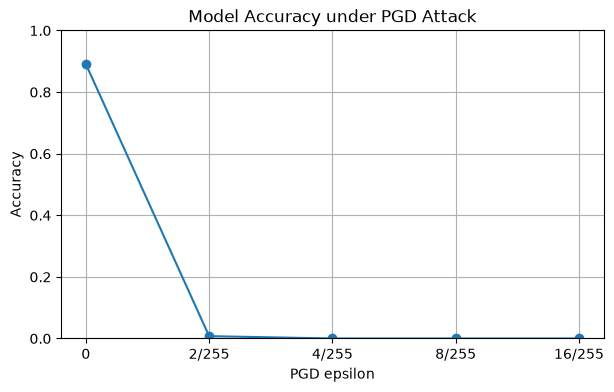

In [60]:
pgd_eps_labels = ["0", "2/255", "4/255", "8/255", "16/255"]
pgd_accuracies = [pgd_results[eps] for eps in PGD_EPSILONS]

plt.figure(figsize=(7, 4))
plt.plot(pgd_eps_labels, pgd_accuracies, marker="o")
plt.xlabel("PGD epsilon")
plt.ylabel("Accuracy")
plt.title("Model Accuracy under PGD Attack")
plt.grid(True)
plt.ylim(0, 1)
plt.show()

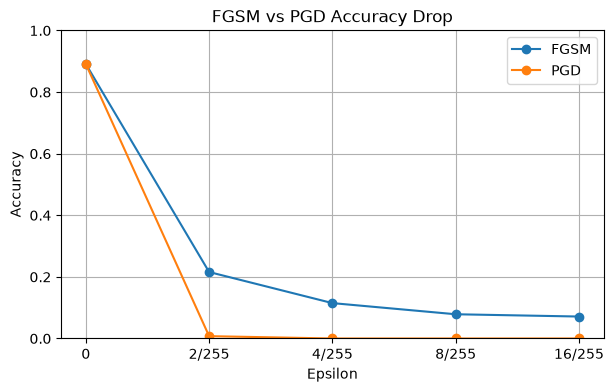

In [61]:
fgsm_accuracies = [fgsm_results[eps] for eps in PGD_EPSILONS]
pgd_accuracies = [pgd_results[eps] for eps in PGD_EPSILONS]

plt.figure(figsize=(7, 4))
plt.plot(pgd_eps_labels, fgsm_accuracies, marker="o", label="FGSM")
plt.plot(pgd_eps_labels, pgd_accuracies, marker="o", label="PGD")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("FGSM vs PGD Accuracy Drop")
plt.grid(True)
plt.ylim(0, 1)
plt.legend()
plt.show()

## DeepFool Attack

DeepFool iteratively linearizes the decision boundaries and searches for a small perturbation that changes the predicted class.

In [62]:
DEEPFOOL_MAX_ITER = 50
DEEPFOOL_NUM_CLASSES = 10
DEEPFOOL_OVERSHOOT = 0.02
DEEPFOOL_EVAL_SIZE = 500

In [63]:
def deepfool_attack_single_image(
    model,
    image,
    device,
    num_classes=10,
    max_iter=50,
    overshoot=0.02
):
    model.eval()

    image = image.clone().detach().to(device)

    with torch.no_grad():
        logits = model(image.unsqueeze(0))
        initial_pred = logits.argmax(dim=1).item()

    adv_image = image.clone().detach()
    perturbation = torch.zeros_like(image).to(device)

    final_pred = initial_pred
    num_iter = 0

    while final_pred == initial_pred and num_iter < max_iter:
        adv_image.requires_grad = True

        logits = model(adv_image.unsqueeze(0)).squeeze(0)

        sorted_classes = torch.argsort(logits, descending=True)
        sorted_classes = sorted_classes[:num_classes]

        current_class = initial_pred

        model.zero_grad()

        current_logit = logits[current_class]
        current_grad = torch.autograd.grad(
            current_logit,
            adv_image,
            retain_graph=True,
            create_graph=False
        )[0]

        min_distance = float("inf")
        best_perturbation = None

        for class_idx in sorted_classes:
            class_idx = class_idx.item()

            if class_idx == current_class:
                continue

            class_logit = logits[class_idx]

            class_grad = torch.autograd.grad(
                class_logit,
                adv_image,
                retain_graph=True,
                create_graph=False
            )[0]

            w_k = class_grad - current_grad
            f_k = class_logit - current_logit

            w_k_norm = torch.norm(w_k.flatten(), p=2)

            if w_k_norm.item() == 0:
                continue

            distance = torch.abs(f_k) / w_k_norm

            if distance.item() < min_distance:
                min_distance = distance.item()
                best_perturbation = (torch.abs(f_k) / (w_k_norm ** 2)) * w_k

        if best_perturbation is None:
            break

        perturbation = perturbation + best_perturbation.detach()

        adv_image = image + (1 + overshoot) * perturbation
        adv_image = torch.clamp(adv_image, 0.0, 1.0).detach()

        with torch.no_grad():
            final_logits = model(adv_image.unsqueeze(0))
            final_pred = final_logits.argmax(dim=1).item()

        num_iter += 1

    success = final_pred != initial_pred
    final_perturbation = adv_image - image

    return adv_image.detach(), final_perturbation.detach(), initial_pred, final_pred, num_iter, success

In [64]:
# Sanity Check

sample_images, sample_labels = next(iter(test_loader))

sample_image = sample_images[0].to(device)
sample_label = sample_labels[0].item()

adv_image, perturbation, initial_pred, final_pred, num_iter, success = deepfool_attack_single_image(
    model,
    sample_image,
    device,
    DEEPFOOL_NUM_CLASSES,
    DEEPFOOL_MAX_ITER,
    DEEPFOOL_OVERSHOOT
)

print("True label:", CIFAR10_CLASSES[sample_label])
print("Initial prediction:", CIFAR10_CLASSES[initial_pred])
print("Final prediction:", CIFAR10_CLASSES[final_pred])
print("Iterations:", num_iter)
print("Success:", success)
print("L2 perturbation:", torch.norm(perturbation.flatten(), p=2).item())
print("Adv min:", adv_image.min().item())
print("Adv max:", adv_image.max().item())

assert adv_image.min().item() >= 0.0
assert adv_image.max().item() <= 1.0

True label: cat
Initial prediction: cat
Final prediction: dog
Iterations: 3
Success: True
L2 perturbation: 0.22979320585727692
Adv min: 0.05060933902859688
Adv max: 0.9996079802513123


In [65]:
def evaluate_deepfool(
    model,
    loader,
    max_samples,
    num_classes,
    max_iter,
    overshoot,
    device
):
    model.eval()

    total_samples = 0
    clean_correct = 0
    adv_correct = 0

    attacked_samples = 0
    successful_attacks = 0
    l2_norm_successful = []

    for images, labels in loader:
        for i in range(images.size(0)):
            if total_samples >= max_samples:
                break

            image = images[i].to(device)
            label = labels[i].to(device)

            with torch.no_grad():
                clean_logits = model(image.unsqueeze(0))
                clean_pred = clean_logits.argmax(dim=1).item()

            total_samples += 1

            if clean_pred == label.item():
                clean_correct += 1

                adv_image, perturbation, initial_pred, final_pred, num_iter, success = deepfool_attack_single_image(
                    model,
                    image,
                    device,
                    num_classes,
                    max_iter,
                    overshoot
                )

                attacked_samples += 1

                with torch.no_grad():
                    adv_logits = model(adv_image.unsqueeze(0))
                    adv_pred = adv_logits.argmax(dim=1).item()

                if adv_pred == label.item():
                    adv_correct += 1
                else:
                    successful_attacks += 1
                    l2_norm = torch.norm(perturbation.flatten(), p=2).item()
                    l2_norm_successful.append(l2_norm)

            if total_samples % 50 == 0:
                print(f"Processed {total_samples}/{max_samples} samples")

        if total_samples >= max_samples:
            break

    clean_accuracy = clean_correct / total_samples
    robust_accuracy = adv_correct / total_samples

    if attacked_samples > 0:
        success_rate = successful_attacks / attacked_samples
    else:
        success_rate = 0.0

    if len(l2_norm_successful) > 0:
        avg_l2_successful = float(np.mean(l2_norm_successful))
    else:
        avg_l2_successful = 0.0

    results = {
        "total_samples": total_samples,
        "clean_correct": clean_correct,
        "clean_accuracy": clean_accuracy,
        "adv_correct": adv_correct,
        "robust_accuracy": robust_accuracy,
        "attacked_samples": attacked_samples,
        "successful_attacks": successful_attacks,
        "success_rate": success_rate,
        "avg_l2_successful": avg_l2_successful
    }

    print("\nDeepFool Results")
    print("----------------")
    print(f"Total samples: {total_samples}")
    print(f"Clean accuracy: {clean_accuracy:.4f}")
    print(f"Robust accuracy after DeepFool: {robust_accuracy:.4f}")
    print(f"Attacked initially correct samples: {attacked_samples}")
    print(f"Successful attacks: {successful_attacks}")
    print(f"Success rate on initially correct samples: {success_rate:.4f}")
    print(f"Average L2 norm on successful attacks: {avg_l2_successful:.6f}")

    return results

In [66]:
deepfool_results = evaluate_deepfool(
    model,
    test_loader,
    max_samples=DEEPFOOL_EVAL_SIZE,
    num_classes=DEEPFOOL_NUM_CLASSES,
    max_iter=DEEPFOOL_MAX_ITER,
    overshoot=DEEPFOOL_OVERSHOOT,
    device=device
)

Processed 50/500 samples
Processed 100/500 samples
Processed 150/500 samples
Processed 200/500 samples
Processed 250/500 samples
Processed 300/500 samples
Processed 350/500 samples
Processed 400/500 samples
Processed 450/500 samples
Processed 500/500 samples

DeepFool Results
----------------
Total samples: 500
Clean accuracy: 0.9180
Robust accuracy after DeepFool: 0.0040
Attacked initially correct samples: 459
Successful attacks: 457
Success rate on initially correct samples: 0.9956
Average L2 norm on successful attacks: 0.114675


In [67]:
def find_deepfool_successful_examples(
    model,
    loader,
    num_classes,
    max_iter,
    overshoot,
    device,
    num_examples=2
):
    model.eval()

    successful_examples = []

    for images, labels in loader:
        for image, label in zip(images, labels):
            image = image.to(device)
            label = label.to(device)

            with torch.no_grad():
                clean_logits = model(image.unsqueeze(0))
                clean_probs = F.softmax(clean_logits, dim=1)
                clean_confidence, clean_pred = clean_probs.max(dim=1)

            if clean_pred.item() != label.item():
                continue

            (
                adv_image,
                perturbation,
                initial_pred,
                final_pred,
                num_iter,
                success
            ) = deepfool_attack_single_image(
                model=model,
                image=image,
                device=device,
                num_classes=num_classes,
                max_iter=max_iter,
                overshoot=overshoot
            )

            if not success:
                continue

            with torch.no_grad():
                adv_logits = model(adv_image.unsqueeze(0))
                adv_probs = F.softmax(adv_logits, dim=1)
                adv_confidence, adv_pred = adv_probs.max(dim=1)

            if adv_pred.item() == label.item():
                continue

            successful_examples.append({
                "clean_image": image.detach().cpu(),
                "adv_image": adv_image.detach().cpu(),
                "perturbation": perturbation.detach().cpu(),
                "label": label.item(),
                "clean_pred": clean_pred.item(),
                "clean_confidence": clean_confidence.item(),
                "adv_pred": adv_pred.item(),
                "adv_confidence": adv_confidence.item(),
                "num_iter": num_iter
            })

            if len(successful_examples) >= num_examples:
                return successful_examples

    raise RuntimeError(
        f"Only {len(successful_examples)} successful DeepFool examples "
        f"were found, but {num_examples} were requested."
    )

In [68]:
def show_deepfool_successful_example(
    model,
    loader,
    num_classes,
    max_iter,
    overshoot,
    class_names,
    device,
    num_examples=2
):
    examples = find_deepfool_successful_examples(
        model=model,
        loader=loader,
        num_classes=num_classes,
        max_iter=max_iter,
        overshoot=overshoot,
        device=device,
        num_examples=num_examples
    )

    fig, axes = plt.subplots(
        num_examples,
        3,
        figsize=(10, 3.5 * num_examples)
    )

    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, example in enumerate(examples):
        clean_image = example["clean_image"]
        adv_image = example["adv_image"]
        perturbation = example["perturbation"]

        l2_norm = torch.norm(
            perturbation.flatten(),
            p=2
        ).item()

        l_inf_norm = perturbation.abs().max().item()

        if l_inf_norm > 0:
            perturbation_display = (
                perturbation / (2 * l_inf_norm)
            ) + 0.5
        else:
            perturbation_display = torch.full_like(
                perturbation,
                0.5
            )

        perturbation_display = torch.clamp(
            perturbation_display,
            0.0,
            1.0
        )

        images_to_show = [
            clean_image,
            perturbation_display,
            adv_image
        ]

        titles = [
            (
                "Clean\n"
                f"Pred: {class_names[example['clean_pred']]}\n"
                f"Conf: {example['clean_confidence']:.2f}"
            ),
            (
                "DeepFool Perturbation\n"
                "Scaled for display\n"
                f"L2: {l2_norm:.4f}\n"
                f"L∞: {l_inf_norm:.5f}"
            ),
            (
                "Adversarial\n"
                f"Pred: {class_names[example['adv_pred']]}\n"
                f"Conf: {example['adv_confidence']:.2f}"
            )
        ]

        for col, image in enumerate(images_to_show):
            image_np = image.permute(1, 2, 0).numpy()
            image_np = np.clip(image_np, 0.0, 1.0)

            axes[row, col].imshow(image_np)
            axes[row, col].set_title(titles[col])
            axes[row, col].axis("off")

        axes[row, 0].set_ylabel(
            (
                f"True: {class_names[example['label']]}\n"
                f"Example {row + 1}\n"
                f"Iterations: {example['num_iter']}"
            ),
            fontsize=10
        )

    fig.suptitle(
        (
            "Successful DeepFool Examples\n"
            f"max_iter={max_iter}, overshoot={overshoot}"
        ),
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

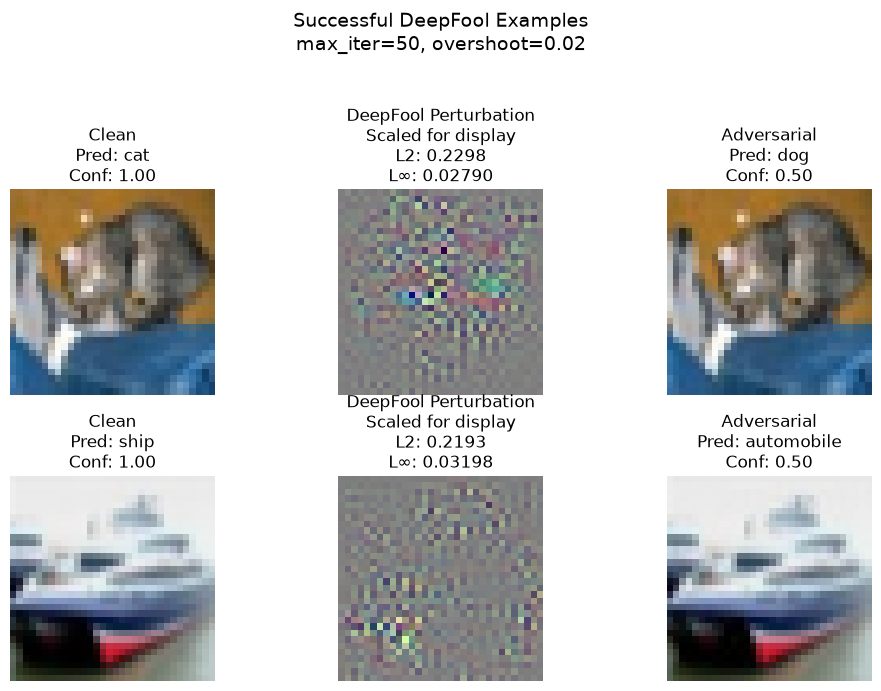

In [69]:
show_deepfool_successful_example(
    model=model,
    loader=test_loader,
    num_classes=DEEPFOOL_NUM_CLASSES,
    max_iter=DEEPFOOL_MAX_ITER,
    overshoot=DEEPFOOL_OVERSHOOT,
    class_names=CIFAR10_CLASSES,
    device=device,
    num_examples=2
)

## Carlini and Wagner Attack

The C&W attack searches for a small adversarial perturbation by solving:

$$
\min_{\delta}
\|\delta\|_2^2+c\,f(x+\delta)
$$

The tanh transformation keeps the generated image inside the valid pixel range.

In [70]:
CW_STEPS = 100
CW_LR = 0.01
CW_C = 1.0
CW_KAPPA = 0.0
CW_EVAL_SIZE = 200

In [71]:
def atanh(x):
    return 0.5 * torch.log((1 + x) / (1 - x))

In [72]:
def image_to_tanh_space(images, eps=1e-6):
    images = torch.clamp(images, eps, 1 - eps)
    return atanh(2 * images - 1)

In [73]:
def tanh_space_to_image(w):
    return 0.5 * (torch.tanh(w) + 1)

In [74]:
def cw_attack(
    model,
    images,
    labels,
    c,
    kappa,
    num_steps,
    lr,
    device
):
    model.eval()

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    batch_size = images.size(0)

    w = image_to_tanh_space(images).detach()
    w.requires_grad = True

    optimizer = torch.optim.Adam([w], lr=lr)

    best_adv_images = images.clone().detach()

    best_l2 = torch.full(
        (batch_size,),
        float("inf"),
        device=device
    )

    best_success = torch.zeros(
        batch_size,
        dtype=torch.bool,
        device=device
    )

    for step in range(num_steps + 1):
        adv_images = tanh_space_to_image(w)

        logits = model(adv_images)

        one_hot_labels = F.one_hot(
            labels,
            num_classes=logits.size(1)
        ).bool()

        true_logits = logits.gather(
            1,
            labels.view(-1, 1)
        ).squeeze(1)

        wrong_logits = logits.masked_fill(
            one_hot_labels,
            -float("inf")
        )

        max_wrong_logits = wrong_logits.max(dim=1).values

        f_loss = torch.clamp(
            true_logits - max_wrong_logits,
            min=-kappa
        )

        l2_loss_per_sample = torch.sum(
            (adv_images - images) ** 2,
            dim=[1, 2, 3]
        )

        with torch.no_grad():
            preds = logits.argmax(dim=1)
            success = preds != labels

            improved = (
                success
                & (l2_loss_per_sample < best_l2)
            )

            best_l2[improved] = l2_loss_per_sample[improved]

            best_adv_images[improved] = (
                adv_images[improved].detach()
            )

            best_success[improved] = True

        if step == num_steps:
            break

        loss = l2_loss_per_sample + c * f_loss
        loss = loss.sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    final_adv_images = best_adv_images.detach().clone()

    with torch.no_grad():
        final_logits = model(final_adv_images)
        final_preds = final_logits.argmax(dim=1)

    return (
        final_adv_images,
        best_success,
        best_l2,
        final_preds
    )

In [75]:
# Sanity Check
sanity_check_images, sanity_check_labels = next(iter(test_loader))

sanity_check_images = sanity_check_images[:8].to(device)
sanity_check_labels = sanity_check_labels[:8].to(device)

sanity_check_adv_images, sanity_check_success, sanity_check_l2, sanity_check_preds = cw_attack(
    model=model,
    images=sanity_check_images,
    labels=sanity_check_labels,
    c=CW_C,
    kappa=CW_KAPPA,
    num_steps=CW_STEPS,
    lr=CW_LR,
    device=device
)

print("Success:", sanity_check_success.detach().cpu().numpy())
print("Preds:", sanity_check_preds.detach().cpu().numpy())
print("Labels:", sanity_check_labels.detach().cpu().numpy())
print("L2:", torch.sqrt(sanity_check_l2).detach().cpu().numpy())
print("Adv min:", sanity_check_adv_images.min().item())
print("Adv max:", sanity_check_adv_images.max().item())

assert sanity_check_adv_images.min().item() >= 0.0
assert sanity_check_adv_images.max().item() <= 1.0

Success: [ True  True  True  True  True  True  True  True]
Preds: [5 1 1 8 3 3 9 2]
Labels: [3 8 8 0 6 6 1 6]
L2: [0.28903005 0.31896615 0.13736863 0.0652164  0.18682377 0.12938303
 0.09012755 0.12703125]
Adv min: 8.344650268554688e-07
Adv max: 0.9999991059303284


In [76]:
def evaluate_cw(
    model,
    loader,
    max_samples,
    c,
    kappa,
    num_steps,
    lr,
    device
):
    model.eval()

    total_samples = 0
    clean_correct = 0
    adv_correct = 0

    attacked_samples = 0
    successful_attacks = 0
    l2_norm_successful = []

    for images, labels in loader:
        remaining = max_samples - total_samples

        if remaining <= 0:
            break

        images = images[:remaining].to(device, non_blocking=True)
        labels = labels[:remaining].to(device, non_blocking=True)

        with torch.no_grad():
            clean_logits = model(images)
            clean_preds = clean_logits.argmax(dim=1)

        initially_correct_mask = clean_preds == labels

        clean_correct += initially_correct_mask.sum().item()
        total_samples += labels.size(0)

        if initially_correct_mask.sum().item() == 0:
            continue

        images_to_attack = images[initially_correct_mask]
        labels_to_attack = labels[initially_correct_mask]

        adv_images, success, best_l2, final_preds = cw_attack(
            model,
            images_to_attack,
            labels_to_attack,
            c,
            kappa,
            num_steps,
            lr,
            device
        )

        attacked_samples += labels_to_attack.size(0)

        with torch.no_grad():
            adv_logits = model(adv_images)
            adv_preds = adv_logits.argmax(dim=1)

        adv_correct += (adv_preds == labels_to_attack).sum().item()

        successful_mask = adv_preds != labels_to_attack
        successful_attacks += successful_mask.sum().item()

        if successful_mask.sum().item() > 0:
            successful_l2 = torch.sqrt(best_l2[successful_mask])
            l2_norm_successful.extend(successful_l2.detach().cpu().tolist())

        print(f"Processed {total_samples}/{max_samples} samples")

    clean_accuracy = clean_correct / total_samples
    robust_accuracy = adv_correct / total_samples

    if attacked_samples > 0:
        success_rate = successful_attacks / attacked_samples
    else:
        success_rate = 0.0

    if len(l2_norm_successful) > 0:
        avg_l2_successful = float(np.mean(l2_norm_successful))
    else:
        avg_l2_successful = 0.0

    results = {
        "total_samples": total_samples,
        "clean_correct": clean_correct,
        "clean_accuracy": clean_accuracy,
        "adv_correct": adv_correct,
        "robust_accuracy": robust_accuracy,
        "attacked_samples": attacked_samples,
        "successful_attacks": successful_attacks,
        "success_rate": success_rate,
        "avg_l2_successful": avg_l2_successful
    }

    print("\nC&W Results")
    print("-----------")
    print(f"Total samples: {total_samples}")
    print(f"Clean accuracy: {clean_accuracy:.4f}")
    print(f"Robust accuracy after C&W: {robust_accuracy:.4f}")
    print(f"Attacked initially correct samples: {attacked_samples}")
    print(f"Successful attacks: {successful_attacks}")
    print(f"Success rate on initially correct samples: {success_rate:.4f}")
    print(f"Average L2 norm on successful attacks: {avg_l2_successful:.6f}")

    return results

In [77]:
cw_results = evaluate_cw(
    model,
    test_loader,
    CW_EVAL_SIZE,
    CW_C,
    CW_KAPPA,
    CW_STEPS,
    CW_LR,
    device
)

Processed 128/200 samples
Processed 200/200 samples

C&W Results
-----------
Total samples: 200
Clean accuracy: 0.9100
Robust accuracy after C&W: 0.0000
Attacked initially correct samples: 182
Successful attacks: 182
Success rate on initially correct samples: 1.0000
Average L2 norm on successful attacks: 0.190003


In [78]:
def find_cw_successful_examples(
    model,
    loader,
    c,
    kappa,
    num_steps,
    lr,
    device,
    num_examples=2
):
    model.eval()

    successful_examples = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.no_grad():
            clean_logits = model(images)
            clean_probs = F.softmax(clean_logits, dim=1)
            clean_confidences, clean_preds = clean_probs.max(dim=1)

        correct_mask = clean_preds == labels

        if not correct_mask.any():
            continue

        clean_images = images[correct_mask]
        clean_labels = labels[correct_mask]
        clean_preds = clean_preds[correct_mask]
        clean_confidences = clean_confidences[correct_mask]

        adv_images, success, best_l2, final_preds = cw_attack(
            model=model,
            images=clean_images,
            labels=clean_labels,
            c=c,
            kappa=kappa,
            num_steps=num_steps,
            lr=lr,
            device=device
        )

        with torch.no_grad():
            adv_logits = model(adv_images)
            adv_probs = F.softmax(adv_logits, dim=1)
            adv_confidences, adv_preds = adv_probs.max(dim=1)

        successful_mask = success & (adv_preds != clean_labels)

        successful_indices = successful_mask.nonzero(
            as_tuple=True
        )[0]

        for sample_idx in successful_indices:
            successful_examples.append({
                "clean_image": (
                    clean_images[sample_idx]
                    .detach()
                    .cpu()
                ),
                "adv_image": (
                    adv_images[sample_idx]
                    .detach()
                    .cpu()
                ),
                "label": clean_labels[sample_idx].item(),
                "clean_pred": clean_preds[sample_idx].item(),
                "clean_confidence": (
                    clean_confidences[sample_idx].item()
                ),
                "adv_pred": adv_preds[sample_idx].item(),
                "adv_confidence": (
                    adv_confidences[sample_idx].item()
                ),
                "l2_norm": torch.sqrt(
                    best_l2[sample_idx]
                ).item()
            })

            if len(successful_examples) >= num_examples:
                return successful_examples

    raise RuntimeError(
        f"Only {len(successful_examples)} successful C&W examples "
        f"were found, but {num_examples} were requested."
    )

In [79]:
def show_cw_successful_example(
    model,
    loader,
    c,
    kappa,
    num_steps,
    lr,
    class_names,
    device,
    num_examples=2
):
    examples = find_cw_successful_examples(
        model=model,
        loader=loader,
        c=c,
        kappa=kappa,
        num_steps=num_steps,
        lr=lr,
        device=device,
        num_examples=num_examples
    )

    fig, axes = plt.subplots(
        num_examples,
        3,
        figsize=(10, 3.5 * num_examples)
    )

    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, example in enumerate(examples):
        clean_image = example["clean_image"]
        adv_image = example["adv_image"]

        perturbation = adv_image - clean_image

        l2_norm = example["l2_norm"]
        l_inf_norm = perturbation.abs().max().item()

        if l_inf_norm > 0:
            perturbation_display = (
                perturbation / (2 * l_inf_norm)
            ) + 0.5
        else:
            perturbation_display = torch.full_like(
                perturbation,
                0.5
            )

        perturbation_display = torch.clamp(
            perturbation_display,
            0.0,
            1.0
        )

        images_to_show = [
            clean_image,
            perturbation_display,
            adv_image
        ]

        titles = [
            (
                "Clean\n"
                f"Pred: {class_names[example['clean_pred']]}\n"
                f"Conf: {example['clean_confidence']:.2f}"
            ),
            (
                "C&W Perturbation\n"
                "Scaled for display\n"
                f"L2: {l2_norm:.4f}\n"
                f"L∞: {l_inf_norm:.5f}"
            ),
            (
                "Adversarial\n"
                f"Pred: {class_names[example['adv_pred']]}\n"
                f"Conf: {example['adv_confidence']:.2f}"
            )
        ]

        for col, image in enumerate(images_to_show):
            image_np = (
                image
                .permute(1, 2, 0)
                .numpy()
            )

            image_np = np.clip(
                image_np,
                0.0,
                1.0
            )

            axes[row, col].imshow(image_np)
            axes[row, col].set_title(titles[col])
            axes[row, col].axis("off")

        axes[row, 0].set_ylabel(
            (
                f"True: {class_names[example['label']]}\n"
                f"Example {row + 1}"
            ),
            fontsize=11
        )

    fig.suptitle(
        (
            "Successful C&W Examples\n"
            f"c={c}, κ={kappa}, "
            f"steps={num_steps}, lr={lr}"
        ),
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

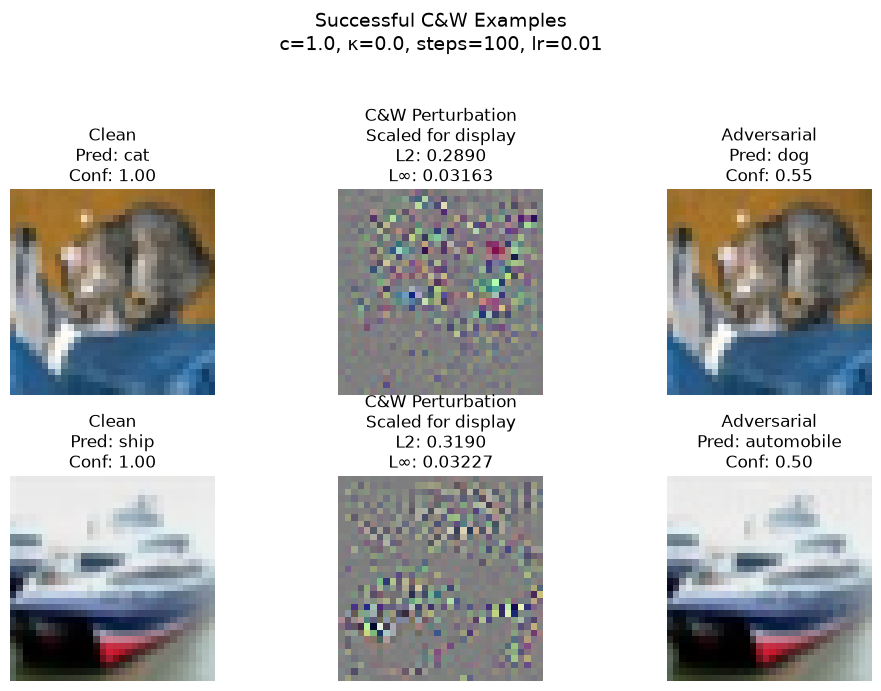

In [80]:
show_cw_successful_example(
    model=model,
    loader=test_loader,
    c=CW_C,
    kappa=CW_KAPPA,
    num_steps=CW_STEPS,
    lr=CW_LR,
    class_names=CIFAR10_CLASSES,
    device=device,
    num_examples=2
)

## Attack Comparison

The four attacks are applied to the same correctly classified image for visual comparison.

In [81]:
COMMON_SAMPLE_IDX = 20
COMMON_EPSILON = 8 / 255

In [82]:
def show_common_attack_example(
    model,
    loader,
    criterion,
    class_names,
    device,
    idx,
    fgsm_epsilon,
    pgd_epsilon,
    pgd_alpha,
    pgd_num_steps,
    pgd_random_start,
    deepfool_num_classes,
    deepfool_max_iter,
    deepfool_overshoot,
    cw_c,
    cw_kappa,
    cw_num_steps,
    cw_lr
):
    model.eval()

    clean_image, label = find_correct_sample(
        model=model,
        loader=loader,
        device=device,
        idx=idx
    )

    clean_image = clean_image.to(device)
    label = label.to(device)

    true_label = label.item()

    def predict(image):
        with torch.no_grad():
            logits = model(image.unsqueeze(0))
            probabilities = F.softmax(logits, dim=1)
            confidence, prediction = probabilities.max(dim=1)

        return confidence.item(), prediction.item()

    def prepare_perturbation_for_display(
        perturbation,
        epsilon=None
    ):
        if epsilon is not None and epsilon > 0:
            display = perturbation / (2 * epsilon) + 0.5
        else:
            max_abs = perturbation.abs().max().item()

            if max_abs > 0:
                display = perturbation / (2 * max_abs) + 0.5
            else:
                display = torch.full_like(
                    perturbation,
                    0.5
                )

        return torch.clamp(display, 0.0, 1.0)

    # FGSM
    fgsm_adv = fgsm_attack(
        model=model,
        images=clean_image.unsqueeze(0),
        labels=label.unsqueeze(0),
        epsilon=fgsm_epsilon,
        criterion=criterion,
        device=device
    ).squeeze(0)

    # PGD
    pgd_adv = pgd_attack(
        model=model,
        images=clean_image.unsqueeze(0),
        labels=label.unsqueeze(0),
        epsilon=pgd_epsilon,
        alpha=pgd_alpha,
        num_steps=pgd_num_steps,
        criterion=criterion,
        device=device,
        random_start=pgd_random_start
    ).squeeze(0)

    # DeepFool
    (
        deepfool_adv,
        deepfool_perturbation,
        _,
        _,
        deepfool_iterations,
        deepfool_success
    ) = deepfool_attack_single_image(
        model=model,
        image=clean_image,
        device=device,
        num_classes=deepfool_num_classes,
        max_iter=deepfool_max_iter,
        overshoot=deepfool_overshoot
    )

    # C&W
    (
        cw_adv_batch,
        cw_success_batch,
        _,
        _
    ) = cw_attack(
        model=model,
        images=clean_image.unsqueeze(0),
        labels=label.unsqueeze(0),
        c=cw_c,
        kappa=cw_kappa,
        num_steps=cw_num_steps,
        lr=cw_lr,
        device=device
    )

    cw_adv = cw_adv_batch.squeeze(0)
    cw_success = bool(cw_success_batch[0].item())

    attack_results = {
        "FGSM": {
            "adv_image": fgsm_adv,
            "epsilon": fgsm_epsilon,
            "details": f"ε={fgsm_epsilon:.5f}"
        },
        "PGD": {
            "adv_image": pgd_adv,
            "epsilon": pgd_epsilon,
            "details": (
                f"ε={pgd_epsilon:.5f}, "
                f"steps={pgd_num_steps}"
            )
        },
        "DeepFool": {
            "adv_image": deepfool_adv,
            "epsilon": None,
            "details": (
                f"iterations={deepfool_iterations}, "
                f"reported success={deepfool_success}"
            )
        },
        "C&W": {
            "adv_image": cw_adv,
            "epsilon": None,
            "details": (
                f"steps={cw_num_steps}, "
                f"reported success={cw_success}"
            )
        }
    }

    clean_confidence, clean_pred = predict(clean_image)

    fig, axes = plt.subplots(
        len(attack_results),
        3,
        figsize=(11, 13)
    )

    for row, (attack_name, result) in enumerate(
        attack_results.items()
    ):
        adv_image = result["adv_image"].detach()
        perturbation = adv_image - clean_image

        perturbation_display = (
            prepare_perturbation_for_display(
                perturbation=perturbation,
                epsilon=result["epsilon"]
            )
        )

        adv_confidence, adv_pred = predict(adv_image)
        attack_success = adv_pred != true_label

        l2_norm = torch.norm(
            perturbation.flatten(),
            p=2
        ).item()

        l_inf_norm = perturbation.abs().max().item()

        images_to_show = [
            clean_image.detach().cpu(),
            perturbation_display.detach().cpu(),
            adv_image.detach().cpu()
        ]

        titles = [
            (
                "Clean\n"
                f"Pred: {class_names[clean_pred]}\n"
                f"Conf: {clean_confidence:.2f}"
            ),
            (
                "Perturbation\n"
                "Scaled for display\n"
                f"L2: {l2_norm:.4f}\n"
                f"L∞: {l_inf_norm:.5f}"
            ),
            (
                "Adversarial\n"
                f"Pred: {class_names[adv_pred]}\n"
                f"Conf: {adv_confidence:.2f}\n"
                f"Success: {attack_success}"
            )
        ]

        for col, image in enumerate(images_to_show):
            image_np = image.permute(1, 2, 0).numpy()
            image_np = np.clip(image_np, 0.0, 1.0)

            axes[row, col].imshow(image_np)
            axes[row, col].set_title(titles[col])
            axes[row, col].axis("off")

        axes[row, 0].set_ylabel(
            f"{attack_name}\n{result['details']}",
            fontsize=10
        )

    fig.suptitle(
        (
            "Comparison of All Attacks on the Same Image\n"
            f"True Label: {class_names[true_label]}"
        ),
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

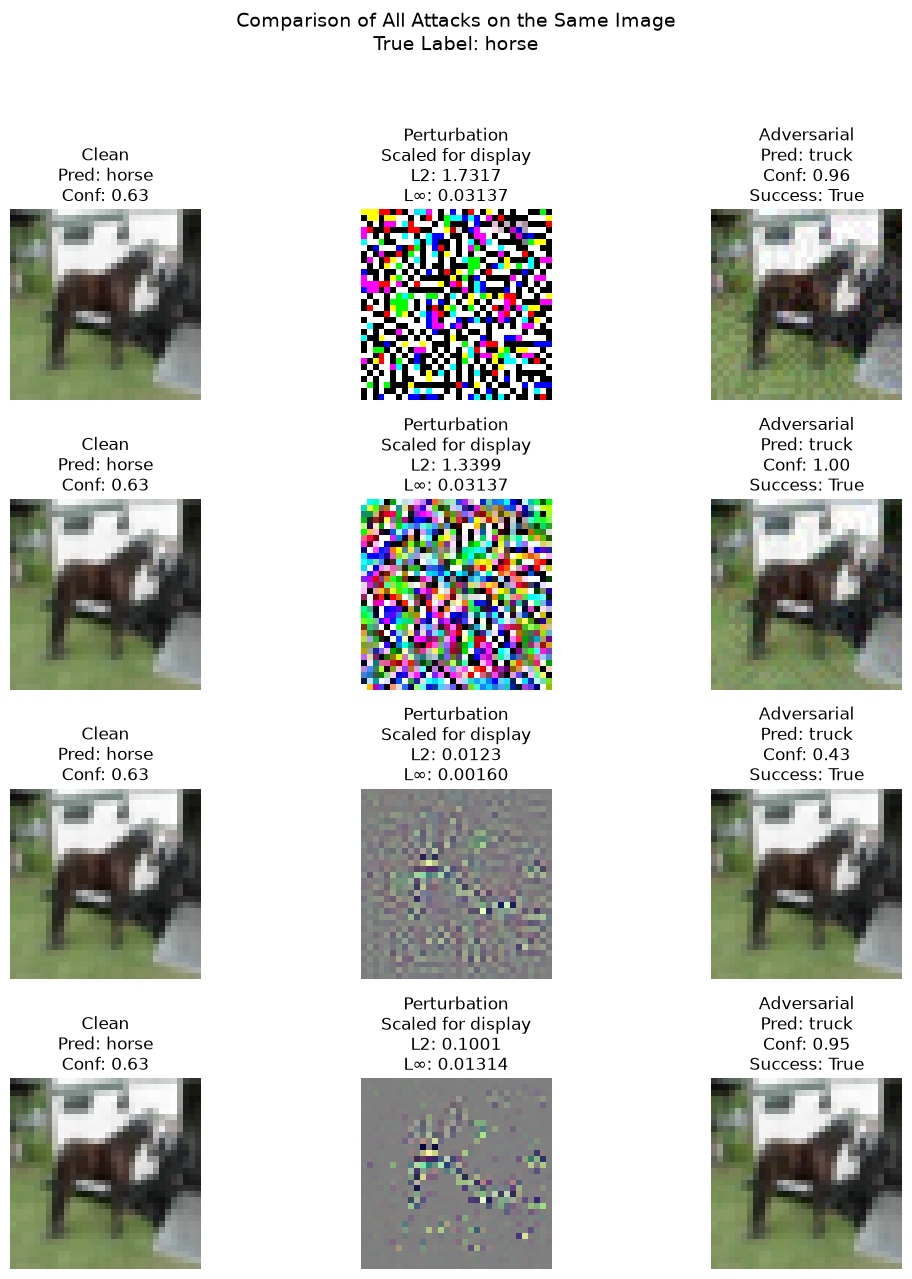

In [83]:
show_common_attack_example(
    model=model,
    loader=test_loader,
    criterion=criterion,
    class_names=CIFAR10_CLASSES,
    device=device,
    idx=COMMON_SAMPLE_IDX,

    fgsm_epsilon=COMMON_EPSILON,

    pgd_epsilon=COMMON_EPSILON,
    pgd_alpha=PGD_ALPHA,
    pgd_num_steps=PGD_STEPS,
    pgd_random_start=PGD_RANDOM_START,

    deepfool_num_classes=DEEPFOOL_NUM_CLASSES,
    deepfool_max_iter=DEEPFOOL_MAX_ITER,
    deepfool_overshoot=DEEPFOOL_OVERSHOOT,

    cw_c=CW_C,
    cw_kappa=CW_KAPPA,
    cw_num_steps=CW_STEPS,
    cw_lr=CW_LR
)

## Adversarial Training

The model is fine-tuned using adversarial examples generated by 10-step PGD:

$$
\min_{\theta}\mathbb{E}_{(x,y)}
\left[
\max_{\delta \in B_{\epsilon}}
L(\theta,x+\delta,y)
\right]
$$

In [84]:
ADV_TRAIN_EPOCHS = 15
ADV_TRAIN_LR = 0.1
ADV_TRAIN_MOMENTUM = 0.9
ADV_TRAIN_WEIGHT_DECAY = 5e-4

ADV_TRAIN_PGD_EPSILON = 8 / 255
ADV_TRAIN_PGD_ALPHA = 2 / 255
ADV_TRAIN_PGD_STEPS = 10
ADV_TRAIN_PGD_RANDOM_START = True

ADV_SAVE_PATH = CHECKPOINTS_DIR / "resnet20_cifar10_adversarial_training.pth"


In [85]:
adv_model = build_resnet20_model(cifar10_mean, cifar10_std, device, 10)
adv_model

Sequential(
  (0): Normalize()
  (1): ResNet20(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=

In [86]:
adv_model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
adv_model = adv_model.to(device)
print("Initialized adversarial training model from clean checkpoint.")

Initialized adversarial training model from clean checkpoint.


In [87]:
def adversarial_train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    epsilon,
    alpha,
    num_steps,
    random_start=True
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        adv_images = pgd_attack(
            model,
            images,
            labels,
            epsilon,
            alpha,
            num_steps,
            criterion,
            device,
            random_start
        )

        model.train()

        logits = model(adv_images)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [88]:
adv_saved_model_exists = False

In [89]:
if ADV_SAVE_PATH.exists():
    adv_model.load_state_dict(torch.load(ADV_SAVE_PATH, map_location=device))
    adv_model = adv_model.to(device)
    adv_model.eval()

    adv_saved_model_exists = True

    print(f"Loaded adversarially trained model from: {ADV_SAVE_PATH}")
else:
    print("No adversarially trained model found. Starting adversarial training.")


No adversarially trained model found. Starting adversarial training.


In [90]:
if not adv_saved_model_exists:
    adv_criterion = nn.CrossEntropyLoss()

    adv_optimizer = torch.optim.SGD(
        adv_model.parameters(),
        lr=ADV_TRAIN_LR,
        momentum=ADV_TRAIN_MOMENTUM,
        weight_decay=ADV_TRAIN_WEIGHT_DECAY
    )

    adv_scheduler = torch.optim.lr_scheduler.MultiStepLR(
        adv_optimizer,
        milestones=[6, 10],
        gamma=0.1
    )

    adv_history = {
        "train_loss": [],
        "train_acc": [],
        "clean_val_loss": [],
        "clean_val_acc": [],
        "robust_val_acc": []
    }

    best_robust_val_acc = -float("inf")
    best_clean_val_acc = -float("inf")
    best_epoch = 0

    for epoch in range(ADV_TRAIN_EPOCHS):
        start_time = time.time()

        train_loss, train_acc = adversarial_train_one_epoch(
            model=adv_model,
            loader=train_loader,
            optimizer=adv_optimizer,
            criterion=adv_criterion,
            device=device,
            epsilon=ADV_TRAIN_PGD_EPSILON,
            alpha=ADV_TRAIN_PGD_ALPHA,
            num_steps=ADV_TRAIN_PGD_STEPS,
            random_start=ADV_TRAIN_PGD_RANDOM_START
        )

        clean_val_loss, clean_val_acc = evaluate(
            model=adv_model,
            loader=val_loader,
            criterion=adv_criterion,
            device=device
        )

        robust_val_acc = evaluate_pgd(
            model=adv_model,
            loader=val_loader,
            epsilon=ADV_TRAIN_PGD_EPSILON,
            alpha=ADV_TRAIN_PGD_ALPHA,
            num_steps=ADV_TRAIN_PGD_STEPS,
            criterion=adv_criterion,
            device=device,
            random_start=ADV_TRAIN_PGD_RANDOM_START
        )

        current_lr = adv_optimizer.param_groups[0]["lr"]

        adv_history["train_loss"].append(train_loss)
        adv_history["train_acc"].append(train_acc)
        adv_history["clean_val_loss"].append(clean_val_loss)
        adv_history["clean_val_acc"].append(clean_val_acc)
        adv_history["robust_val_acc"].append(robust_val_acc)

        if robust_val_acc > best_robust_val_acc:
            best_robust_val_acc = robust_val_acc
            best_clean_val_acc = clean_val_acc
            best_epoch = epoch + 1

            torch.save(
                adv_model.state_dict(),
                ADV_SAVE_PATH
            )

        elapsed = time.time() - start_time

        print(
            f"Epoch [{epoch + 1:02d}/{ADV_TRAIN_EPOCHS}] "
            f"adv_train_loss={train_loss:.4f} "
            f"adv_train_acc={train_acc:.4f} "
            f"clean_val_loss={clean_val_loss:.4f} "
            f"clean_val_acc={clean_val_acc:.4f} "
            f"robust_val_acc={robust_val_acc:.4f} "
            f"lr={current_lr:.5f} "
            f"time={elapsed:.1f}s"
        )

        adv_scheduler.step()

    print(
        f"Best epoch: {best_epoch}\n"
        f"Best robust validation accuracy: "
        f"{best_robust_val_acc:.4f}\n"
        f"Clean validation accuracy at best robust epoch: "
        f"{best_clean_val_acc:.4f}\n"
        f"Saved adversarially trained model: {ADV_SAVE_PATH}"
    )

else:
    print(
        "Skipping adversarial training because "
        "a robust checkpoint already exists."
    )

PGD accuracy | epsilon=0.03137, alpha=0.00784, steps=10: 0.2680
Epoch [01/15] adv_train_loss=2.0950 adv_train_acc=0.2406 clean_val_loss=1.6025 clean_val_acc=0.4164 robust_val_acc=0.2680 lr=0.10000 time=260.6s
PGD accuracy | epsilon=0.03137, alpha=0.00784, steps=10: 0.2816
Epoch [02/15] adv_train_loss=1.8875 adv_train_acc=0.2902 clean_val_loss=1.4817 clean_val_acc=0.5108 robust_val_acc=0.2816 lr=0.10000 time=260.5s
PGD accuracy | epsilon=0.03137, alpha=0.00784, steps=10: 0.3072
Epoch [03/15] adv_train_loss=1.8146 adv_train_acc=0.3167 clean_val_loss=1.3473 clean_val_acc=0.5470 robust_val_acc=0.3072 lr=0.10000 time=267.2s
PGD accuracy | epsilon=0.03137, alpha=0.00784, steps=10: 0.3024
Epoch [04/15] adv_train_loss=1.7683 adv_train_acc=0.3327 clean_val_loss=1.3521 clean_val_acc=0.5476 robust_val_acc=0.3024 lr=0.10000 time=271.6s
PGD accuracy | epsilon=0.03137, alpha=0.00784, steps=10: 0.3042
Epoch [05/15] adv_train_loss=1.7350 adv_train_acc=0.3482 clean_val_loss=1.2729 clean_val_acc=0.5652 

In [91]:
if not adv_saved_model_exists:
    adv_model.load_state_dict(torch.load(ADV_SAVE_PATH, map_location=device))
    adv_model = adv_model.to(device)
    adv_model.eval()

    print("Loaded best adversarially trained model.")

Loaded best adversarially trained model.


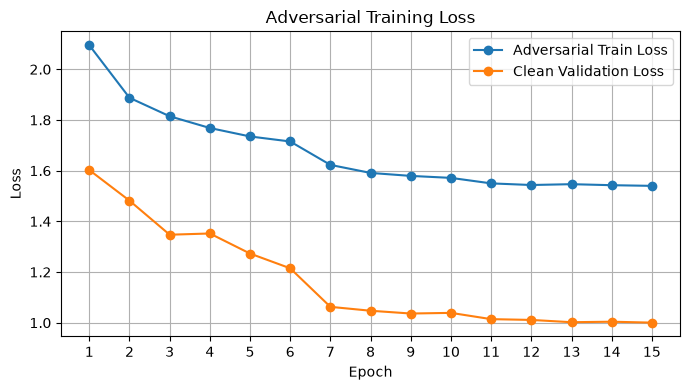

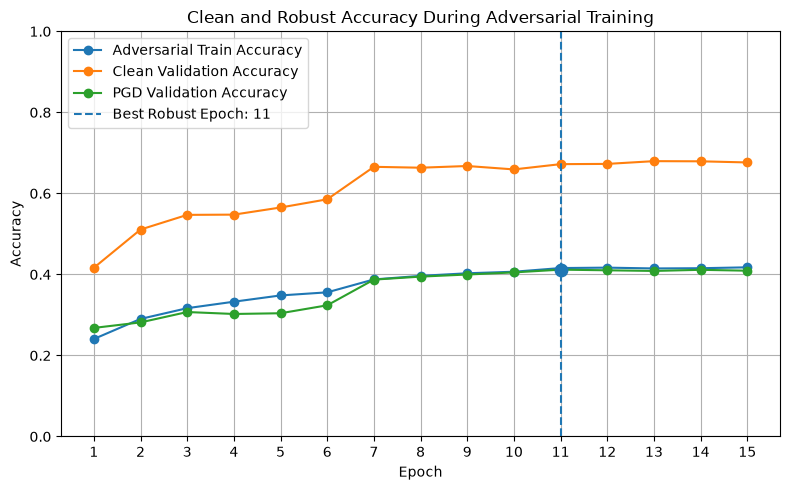

In [92]:
if not adv_saved_model_exists:
    epochs = range(1, len(adv_history["train_loss"]) + 1)

    # Loss curves
    plt.figure(figsize=(7, 4))

    plt.plot(
        epochs,
        adv_history["train_loss"],
        marker="o",
        label="Adversarial Train Loss"
    )

    plt.plot(
        epochs,
        adv_history["clean_val_loss"],
        marker="o",
        label="Clean Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Adversarial Training Loss")
    plt.xticks(epochs)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Accuracy curves
    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        adv_history["train_acc"],
        marker="o",
        label="Adversarial Train Accuracy"
    )

    plt.plot(
        epochs,
        adv_history["clean_val_acc"],
        marker="o",
        label="Clean Validation Accuracy"
    )

    plt.plot(
        epochs,
        adv_history["robust_val_acc"],
        marker="o",
        label="PGD Validation Accuracy"
    )

    plt.axvline(
        x=best_epoch,
        linestyle="--",
        label=f"Best Robust Epoch: {best_epoch}"
    )

    plt.scatter(
        best_epoch,
        adv_history["robust_val_acc"][best_epoch - 1],
        s=80,
        zorder=3
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Clean and Robust Accuracy During Adversarial Training")
    plt.xticks(epochs)
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print(
        "Training history is not available because "
        "the adversarial checkpoint was loaded from disk."
    )

## Robustness Evaluation

The baseline and adversarially trained models are evaluated against all implemented attacks.

In [93]:
COMPARE_FGSM_EPSILON = 8 / 255

COMPARE_PGD_EPSILON = 8 / 255
COMPARE_PGD_ALPHA = 2 / 255
COMPARE_PGD_STEPS = 20
COMPARE_PGD_RANDOM_START = True

COMPARE_DEEPFOOL_EVAL_SIZE = 500
COMPARE_CW_EVAL_SIZE = 200

In [94]:
def evaluate_model_against_attacks(
    model,
    model_name,
    test_loader,
    criterion,
    device
):
    print(f"\n==============================")
    print(f"Evaluating: {model_name}")
    print(f"==============================")

    results = {}

    # Clean
    clean_loss, clean_acc = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=device
    )
    results["Clean"] = clean_acc

    print(f"Clean accuracy: {clean_acc:.4f}")

    # FGSM
    fgsm_result = evaluate_fgsm(
        model=model,
        loader=test_loader,
        epsilons=[COMPARE_FGSM_EPSILON],
        criterion=criterion,
        device=device
    )
    results["FGSM"] = fgsm_result[COMPARE_FGSM_EPSILON]

    # PGD
    pgd_acc = evaluate_pgd(
        model=model,
        loader=test_loader,
        epsilon=COMPARE_PGD_EPSILON,
        alpha=COMPARE_PGD_ALPHA,
        num_steps=COMPARE_PGD_STEPS,
        criterion=criterion,
        device=device,
        random_start=COMPARE_PGD_RANDOM_START
    )
    results["PGD"] = pgd_acc

    # DeepFool
    deepfool_result = evaluate_deepfool(
        model=model,
        loader=test_loader,
        max_samples=COMPARE_DEEPFOOL_EVAL_SIZE,
        num_classes=DEEPFOOL_NUM_CLASSES,
        max_iter=DEEPFOOL_MAX_ITER,
        overshoot=DEEPFOOL_OVERSHOOT,
        device=device
    )
    results["DeepFool"] = deepfool_result["robust_accuracy"]

    # C&W
    cw_result = evaluate_cw(
        model=model,
        loader=test_loader,
        max_samples=COMPARE_CW_EVAL_SIZE,
        c=CW_C,
        kappa=CW_KAPPA,
        num_steps=CW_STEPS,
        lr=CW_LR,
        device=device
    )
    results["C&W"] = cw_result["robust_accuracy"]

    return results

In [95]:
base_model_results = evaluate_model_against_attacks(
    model=model,
    model_name="Base Clean Model",
    test_loader=test_loader,
    criterion=criterion,
    device=device
)

adv_model_results = evaluate_model_against_attacks(
    model=adv_model,
    model_name="Adversarially Trained Model",
    test_loader=test_loader,
    criterion=criterion,
    device=device
)


Evaluating: Base Clean Model
Clean accuracy: 0.8912
epsilon=0.03137 | accuracy=0.0787
PGD accuracy | epsilon=0.03137, alpha=0.00784, steps=20: 0.0000
Processed 50/500 samples
Processed 100/500 samples
Processed 150/500 samples
Processed 200/500 samples
Processed 250/500 samples
Processed 300/500 samples
Processed 350/500 samples
Processed 400/500 samples
Processed 450/500 samples
Processed 500/500 samples

DeepFool Results
----------------
Total samples: 500
Clean accuracy: 0.9180
Robust accuracy after DeepFool: 0.0020
Attacked initially correct samples: 459
Successful attacks: 458
Success rate on initially correct samples: 0.9978
Average L2 norm on successful attacks: 0.114729
Processed 128/200 samples
Processed 200/200 samples

C&W Results
-----------
Total samples: 200
Clean accuracy: 0.9100
Robust accuracy after C&W: 0.0000
Attacked initially correct samples: 182
Successful attacks: 182
Success rate on initially correct samples: 1.0000
Average L2 norm on successful attacks: 0.1900

In [96]:
comparison_table = pd.DataFrame(
    {
        "Base Model": base_model_results,
        "Adversarial Training": adv_model_results
    }
).T

comparison_table_percent = comparison_table * 100
comparison_table_percent = comparison_table_percent.round(2)

comparison_table_percent

,Clean,FGSM,PGD,DeepFool,C&W
Base Model,89.12,7.87,0.00,0.2,0.0
Adversarial Training,67.02,42.45,39.09,0.2,37.5


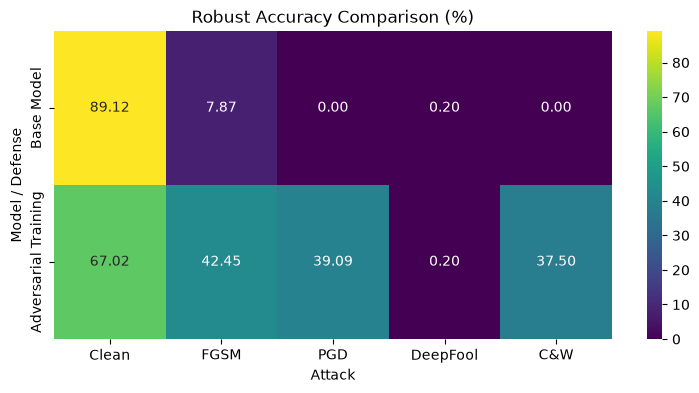

In [97]:
plt.figure(figsize=(9, 4))

sns.heatmap(
    comparison_table_percent,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Robust Accuracy Comparison (%)")
plt.xlabel("Attack")
plt.ylabel("Model / Defense")
plt.show()

In [98]:
base_deepfool_details = evaluate_deepfool(
    model=model,
    loader=test_loader,
    max_samples=COMPARE_DEEPFOOL_EVAL_SIZE,
    num_classes=DEEPFOOL_NUM_CLASSES,
    max_iter=DEEPFOOL_MAX_ITER,
    overshoot=DEEPFOOL_OVERSHOOT,
    device=device
)

adv_deepfool_details = evaluate_deepfool(
    model=adv_model,
    loader=test_loader,
    max_samples=COMPARE_DEEPFOOL_EVAL_SIZE,
    num_classes=DEEPFOOL_NUM_CLASSES,
    max_iter=DEEPFOOL_MAX_ITER,
    overshoot=DEEPFOOL_OVERSHOOT,
    device=device
)

deepfool_comparison = pd.DataFrame({
    "Base Model": base_deepfool_details,
    "Adversarial Training": adv_deepfool_details
}).T

deepfool_comparison[[
    "clean_accuracy",
    "robust_accuracy",
    "attacked_samples",
    "successful_attacks",
    "success_rate",
    "avg_l2_successful"
]]

Processed 50/500 samples
Processed 100/500 samples
Processed 150/500 samples
Processed 200/500 samples
Processed 250/500 samples
Processed 300/500 samples
Processed 350/500 samples
Processed 400/500 samples
Processed 450/500 samples
Processed 500/500 samples

DeepFool Results
----------------
Total samples: 500
Clean accuracy: 0.9180
Robust accuracy after DeepFool: 0.0020
Attacked initially correct samples: 459
Successful attacks: 458
Success rate on initially correct samples: 0.9978
Average L2 norm on successful attacks: 0.114680
Processed 50/500 samples
Processed 100/500 samples
Processed 150/500 samples
Processed 200/500 samples
Processed 250/500 samples
Processed 300/500 samples
Processed 350/500 samples
Processed 400/500 samples
Processed 450/500 samples
Processed 500/500 samples

DeepFool Results
----------------
Total samples: 500
Clean accuracy: 0.6660
Robust accuracy after DeepFool: 0.0080
Attacked initially correct samples: 333
Successful attacks: 329
Success rate on initiall

,clean_accuracy,robust_accuracy,attacked_samples,successful_attacks,success_rate,avg_l2_successful
Base Model,0.918,0.002,459.0,458.0,0.997821,0.114680
Adversarial Training,0.666,0.008,333.0,329.0,0.987988,1.258895


## Randomized Smoothing

The model is fine-tuned with Gaussian noise. At inference time, the final prediction is selected by majority voting over multiple noisy samples.

In [99]:
SMOOTH_EPOCHS = 20
SMOOTH_LR = 0.1
SMOOTH_MOMENTUM = 0.9
SMOOTH_WEIGHT_DECAY = 5e-4

SMOOTH_SIGMA = 0.25
SMOOTH_NUM_SAMPLES = 100

SMOOTH_SAVE_PATH = CHECKPOINTS_DIR / "resnet20_cifar10_randomized_smoothing.pth"


In [100]:
smooth_model = build_resnet20_model(cifar10_mean, cifar10_std, device, 10)
smooth_model

Sequential(
  (0): Normalize()
  (1): ResNet20(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (shortcut): Sequential()
      )
      (1): BasicBlock(
        (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(16, 16, kernel_size=

In [101]:
smooth_model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
smooth_model = smooth_model.to(device)

print("Initialized randomized smoothing model from clean checkpoint.")

Initialized randomized smoothing model from clean checkpoint.


In [102]:
def add_gaussian_noise(images, sigma):
    noise = sigma * torch.randn_like(images)
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0.0, 1.0)

    return noisy_images

In [103]:
def gaussian_noise_train_one_sample(
    model,
    loader,
    optimizer,
    criterion,
    device,
    sigma
):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        noisy_images = add_gaussian_noise(images, sigma)

        logits = model(noisy_images)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [104]:
@torch.no_grad()
def evaluate_noisy(
    model,
    loader,
    criterion,
    device,
    sigma
):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        noisy_images = add_gaussian_noise(images, sigma)

        logits = model(noisy_images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [105]:
smooth_saved_model_exists = False

In [106]:
if SMOOTH_SAVE_PATH.exists():
    smooth_model.load_state_dict(torch.load(SMOOTH_SAVE_PATH, map_location=device))
    smooth_model = smooth_model.to(device)
    smooth_model.eval()

    smooth_saved_model_exists = True

    print(f"Loaded randomized smoothing model from: {SMOOTH_SAVE_PATH}")
else:
    print("No randomized smoothing model found. Starting Gaussian noise fine-tuning.")


No randomized smoothing model found. Starting Gaussian noise fine-tuning.


In [107]:
if not smooth_saved_model_exists:
    smooth_criterion = nn.CrossEntropyLoss()

    smooth_optimizer = torch.optim.SGD(
        smooth_model.parameters(),
        lr=SMOOTH_LR,
        momentum=SMOOTH_MOMENTUM,
        weight_decay=SMOOTH_WEIGHT_DECAY
    )

    smooth_scheduler = torch.optim.lr_scheduler.MultiStepLR(
        smooth_optimizer,
        milestones=[5, 15],
        gamma=0.1
    )

    smooth_history = {
        "train_loss": [],
        "train_acc": [],
        "clean_val_loss": [],
        "clean_val_acc": [],
        "noisy_val_loss": [],
        "noisy_val_acc": []
    }

    best_noisy_val_acc = -float("inf")

    for epoch in range(SMOOTH_EPOCHS):
        start_time = time.time()

        train_loss, train_acc = gaussian_noise_train_one_sample(
            smooth_model,
            train_loader,
            smooth_optimizer,
            smooth_criterion,
            device,
            SMOOTH_SIGMA
        )

        clean_val_loss, clean_val_acc = evaluate(
            smooth_model,
            val_loader,
            smooth_criterion,
            device
        )

        noisy_val_loss, noisy_val_acc = evaluate_noisy(
            smooth_model,
            val_loader,
            smooth_criterion,
            device,
            SMOOTH_SIGMA
        )

        smooth_scheduler.step()

        smooth_history["train_loss"].append(train_loss)
        smooth_history["train_acc"].append(train_acc)
        smooth_history["clean_val_loss"].append(clean_val_loss)
        smooth_history["clean_val_acc"].append(clean_val_acc)
        smooth_history["noisy_val_loss"].append(noisy_val_loss)
        smooth_history["noisy_val_acc"].append(noisy_val_acc)

        if noisy_val_acc > best_noisy_val_acc:
            best_noisy_val_acc = noisy_val_acc
            torch.save(smooth_model.state_dict(), SMOOTH_SAVE_PATH)

        elapsed = time.time() - start_time

        print(
            f"Epoch [{epoch + 1:02d}/{SMOOTH_EPOCHS}] "
            f"noisy_train_loss={train_loss:.4f} "
            f"noisy_train_acc={train_acc:.4f} "
            f"clean_val_acc={clean_val_acc:.4f} "
            f"noisy_val_acc={noisy_val_acc:.4f} "
            f"lr={smooth_scheduler.get_last_lr()[0]:.5f} "
            f"time={elapsed:.1f}s"
        )

    print("Best noisy validation accuracy:", best_noisy_val_acc)
    print("Saved randomized smoothing model:", SMOOTH_SAVE_PATH)

else:
    print("Skipping Gaussian noise fine-tuning because saved model already exists.")

Epoch [01/20] noisy_train_loss=1.2906 noisy_train_acc=0.5404 clean_val_acc=0.5664 noisy_val_acc=0.5508 lr=0.10000 time=23.5s
Epoch [02/20] noisy_train_loss=1.1128 noisy_train_acc=0.6069 clean_val_acc=0.5514 noisy_val_acc=0.5442 lr=0.10000 time=23.3s
Epoch [03/20] noisy_train_loss=1.0758 noisy_train_acc=0.6180 clean_val_acc=0.6084 noisy_val_acc=0.5882 lr=0.10000 time=23.6s
Epoch [04/20] noisy_train_loss=1.0593 noisy_train_acc=0.6263 clean_val_acc=0.5686 noisy_val_acc=0.4892 lr=0.10000 time=23.4s
Epoch [05/20] noisy_train_loss=1.0328 noisy_train_acc=0.6368 clean_val_acc=0.5018 noisy_val_acc=0.5124 lr=0.01000 time=23.5s
Epoch [06/20] noisy_train_loss=0.8846 noisy_train_acc=0.6887 clean_val_acc=0.6954 noisy_val_acc=0.7046 lr=0.01000 time=24.6s
Epoch [07/20] noisy_train_loss=0.8349 noisy_train_acc=0.7064 clean_val_acc=0.7000 noisy_val_acc=0.7150 lr=0.01000 time=24.6s
Epoch [08/20] noisy_train_loss=0.8143 noisy_train_acc=0.7154 clean_val_acc=0.7186 noisy_val_acc=0.7186 lr=0.01000 time=23.9s


In [108]:
if not smooth_saved_model_exists:
    smooth_model.load_state_dict(torch.load(SMOOTH_SAVE_PATH, map_location=device))
    smooth_model = smooth_model.to(device)
    smooth_model.eval()

    print("Loaded best randomized smoothing model.")

Loaded best randomized smoothing model.


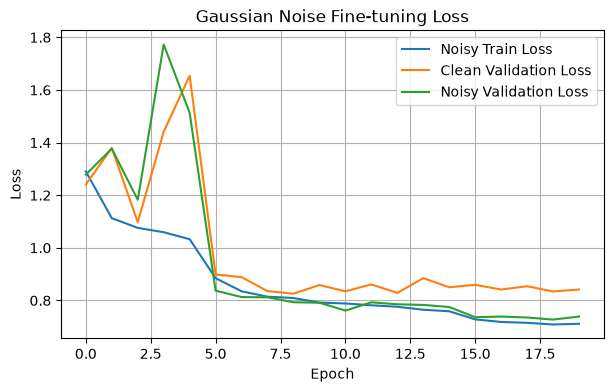

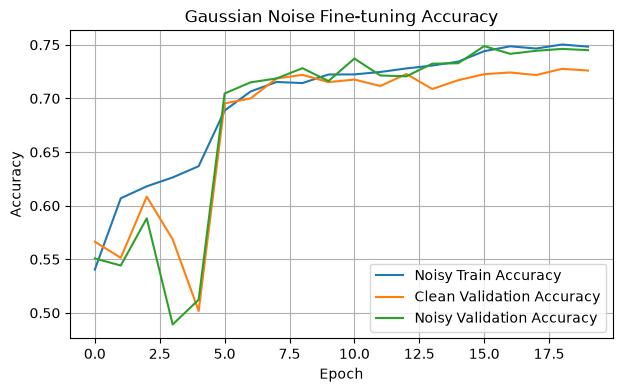

In [109]:
if not smooth_saved_model_exists:
    plt.figure(figsize=(7, 4))
    plt.plot(smooth_history["train_loss"], label="Noisy Train Loss")
    plt.plot(smooth_history["clean_val_loss"], label="Clean Validation Loss")
    plt.plot(smooth_history["noisy_val_loss"], label="Noisy Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Gaussian Noise Fine-tuning Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(smooth_history["train_acc"], label="Noisy Train Accuracy")
    plt.plot(smooth_history["clean_val_acc"], label="Clean Validation Accuracy")
    plt.plot(smooth_history["noisy_val_acc"], label="Noisy Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Gaussian Noise Fine-tuning Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [110]:
smooth_criterion = nn.CrossEntropyLoss()

smooth_clean_test_loss, smooth_clean_test_acc = evaluate(
    model=smooth_model,
    loader=test_loader,
    criterion=smooth_criterion,
    device=device
)

base_noisy_test_loss, base_noisy_test_acc = evaluate_noisy(
    model=model,
    loader=test_loader,
    criterion=smooth_criterion,
    device=device,
    sigma=SMOOTH_SIGMA
)

smooth_noisy_test_loss, smooth_noisy_test_acc = evaluate_noisy(
    model=smooth_model,
    loader=test_loader,
    criterion=smooth_criterion,
    device=device,
    sigma=SMOOTH_SIGMA
)

print(f"Smooth model clean test accuracy: {smooth_clean_test_acc:.4f}")
print(f"Base   model noisy test accuracy: {base_noisy_test_acc:.4f}")
print(f"Smooth model noisy test accuracy: {smooth_noisy_test_acc:.4f}")

Smooth model clean test accuracy: 0.7060
Base   model noisy test accuracy: 0.1085
Smooth model noisy test accuracy: 0.7271


In [111]:
@torch.no_grad()
def randomized_smoothing_predict(
    model,
    images,
    device,
    sigma,
    num_samples,
    num_classes=10
):
    model.eval()

    images = images.to(device)
    batch_size = images.size(0)

    vote_counts = torch.zeros(
        batch_size,
        num_classes,
        device=device
    )

    for _ in range(num_samples):
        noisy_images = add_gaussian_noise(images, sigma)

        logits = model(noisy_images)
        preds = logits.argmax(dim=1)

        vote_counts.scatter_add_(
            dim=1,
            index=preds.view(-1, 1),
            src=torch.ones(batch_size, 1, device=device)
        )

    final_preds = vote_counts.argmax(dim=1)

    return final_preds, vote_counts

In [112]:
@torch.no_grad()
def evaluate_randomized_smoothing(
    model,
    loader,
    device,
    sigma,
    num_samples,
    max_samples=None,
    num_classes=10
):
    model.eval()

    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        if max_samples is not None:
            remaining = max_samples - total_samples

            if remaining <= 0:
                break

            images = images[:remaining]
            labels = labels[:remaining]

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        preds, _ = randomized_smoothing_predict(
            model=model,
            images=images,
            device=device,
            sigma=sigma,
            num_samples=num_samples,
            num_classes=num_classes
        )

        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        print(f"Processed {total_samples} samples")

        if max_samples is not None and total_samples >= max_samples:
            break

    accuracy = total_correct / total_samples

    print(
        f"Randomized smoothing accuracy | "
        f"sigma={sigma}, "
        f"N={num_samples}, "
        f"samples={total_samples}: "
        f"{accuracy:.4f}"
    )

    return accuracy

In [113]:
SMOOTH_EVAL_SIZE = 1000

In [114]:
smooth_clean_acc = evaluate_randomized_smoothing(
    smooth_model,
    test_loader,
    device,
    SMOOTH_SIGMA,
    SMOOTH_NUM_SAMPLES,
    SMOOTH_EVAL_SIZE,
    10
)

print(f"Smoothed clean accuracy: {smooth_clean_acc:.4f}")

Processed 128 samples
Processed 256 samples
Processed 384 samples
Processed 512 samples
Processed 640 samples
Processed 768 samples
Processed 896 samples
Processed 1000 samples
Randomized smoothing accuracy | sigma=0.25, N=100, samples=1000: 0.7930
Smoothed clean accuracy: 0.7930


In [115]:
def evaluate_attack_with_smoothing(
    model,
    loader,
    attack_name,
    criterion,
    device,
    sigma,
    num_smoothing_samples,
    max_samples=None,
    num_classes=10
):
    model.eval()

    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        if max_samples is not None:
            remaining = max_samples - total_samples

            if remaining <= 0:
                break

            images = images[:remaining]
            labels = labels[:remaining]

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if attack_name == "FGSM":
            adv_images = fgsm_attack(
                model=model,
                images=images,
                labels=labels,
                epsilon=COMPARE_FGSM_EPSILON,
                criterion=criterion,
                device=device
            )

        elif attack_name == "PGD":
            adv_images = pgd_attack(
                model=model,
                images=images,
                labels=labels,
                epsilon=COMPARE_PGD_EPSILON,
                alpha=COMPARE_PGD_ALPHA,
                num_steps=COMPARE_PGD_STEPS,
                criterion=criterion,
                device=device,
                random_start=COMPARE_PGD_RANDOM_START
            )

        elif attack_name == "DeepFool":
            adv_images_list = []

            for i in range(images.size(0)):
                image = images[i]
                label = labels[i]

                with torch.no_grad():
                    clean_logits = model(image.unsqueeze(0))
                    clean_pred = clean_logits.argmax(dim=1).item()

                if clean_pred != label.item():
                    adv_images_list.append(image.detach().cpu())
                    continue

                adv_image, perturbation, initial_pred, final_pred, num_iter, success = deepfool_attack_single_image(
                    model=model,
                    image=image,
                    device=device,
                    num_classes=DEEPFOOL_NUM_CLASSES,
                    max_iter=DEEPFOOL_MAX_ITER,
                    overshoot=DEEPFOOL_OVERSHOOT
                )

                adv_images_list.append(adv_image.detach().cpu())

            adv_images = torch.stack(adv_images_list).to(device)

        elif attack_name == "C&W":
            with torch.no_grad():
                clean_logits = model(images)
                clean_preds = clean_logits.argmax(dim=1)

            initially_correct_mask = clean_preds == labels

            adv_images = images.clone().detach()

            if initially_correct_mask.sum().item() > 0:
                images_to_attack = images[initially_correct_mask]
                labels_to_attack = labels[initially_correct_mask]

                cw_adv_images, success, best_l2, final_preds = cw_attack(
                    model=model,
                    images=images_to_attack,
                    labels=labels_to_attack,
                    c=CW_C,
                    kappa=CW_KAPPA,
                    num_steps=CW_STEPS,
                    lr=CW_LR,
                    device=device
                )

                adv_images[initially_correct_mask] = cw_adv_images.detach()

        else:
            raise ValueError(f"Unknown attack name: {attack_name}")

        preds, vote_counts = randomized_smoothing_predict(
            model=model,
            images=adv_images,
            device=device,
            sigma=sigma,
            num_samples=num_smoothing_samples,
            num_classes=num_classes
        )

        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        print(f"{attack_name} + smoothing | Processed {total_samples} samples")

        if max_samples is not None and total_samples >= max_samples:
            break

    accuracy = total_correct / total_samples

    print(f"{attack_name} + smoothing accuracy: {accuracy:.4f}")

    return accuracy

In [116]:
def evaluate_smooth_model_against_attacks(
    model,
    model_name,
    test_loader,
    criterion,
    device,
    sigma,
    num_smoothing_samples,
    max_samples=None,
    num_classes=10
):
    print(f"\n==============================")
    print(f"Evaluating smoothed model: {model_name}")
    print(f"Sigma: {sigma}, N: {num_smoothing_samples}")
    print(f"==============================")

    results = {}

    # ---------------- Clean + Smoothing ----------------
    clean_acc = evaluate_randomized_smoothing(
        model=model,
        loader=test_loader,
        device=device,
        sigma=sigma,
        num_samples=num_smoothing_samples,
        max_samples=max_samples,
        num_classes=num_classes
    )
    results["Clean"] = clean_acc

    # ---------------- FGSM + Smoothing ----------------
    fgsm_acc = evaluate_attack_with_smoothing(
        model=model,
        loader=test_loader,
        attack_name="FGSM",
        criterion=criterion,
        device=device,
        sigma=sigma,
        num_smoothing_samples=num_smoothing_samples,
        max_samples=max_samples,
        num_classes=num_classes
    )
    results["FGSM"] = fgsm_acc

    # ---------------- PGD + Smoothing ----------------
    pgd_acc = evaluate_attack_with_smoothing(
        model=model,
        loader=test_loader,
        attack_name="PGD",
        criterion=criterion,
        device=device,
        sigma=sigma,
        num_smoothing_samples=num_smoothing_samples,
        max_samples=max_samples,
        num_classes=num_classes
    )
    results["PGD"] = pgd_acc

    # ---------------- DeepFool + Smoothing ----------------
    deepfool_acc = evaluate_attack_with_smoothing(
        model=model,
        loader=test_loader,
        attack_name="DeepFool",
        criterion=criterion,
        device=device,
        sigma=sigma,
        num_smoothing_samples=num_smoothing_samples,
        max_samples=max_samples,
        num_classes=num_classes
    )
    results["DeepFool"] = deepfool_acc

    # ---------------- C&W + Smoothing ----------------
    cw_acc = evaluate_attack_with_smoothing(
        model=model,
        loader=test_loader,
        attack_name="C&W",
        criterion=criterion,
        device=device,
        sigma=sigma,
        num_smoothing_samples=num_smoothing_samples,
        max_samples=max_samples,
        num_classes=num_classes
    )
    results["C&W"] = cw_acc

    return results

In [117]:
SMOOTH_COMPARE_EVAL_SIZE = 500

In [118]:
smooth_model_results = evaluate_smooth_model_against_attacks(
    smooth_model,
    "Randomized Smoothing",
    test_loader,
    criterion,
    device,
    SMOOTH_SIGMA,
    SMOOTH_NUM_SAMPLES,
    SMOOTH_COMPARE_EVAL_SIZE,
    10
)

smooth_model_results


Evaluating smoothed model: Randomized Smoothing
Sigma: 0.25, N: 100
Processed 128 samples
Processed 256 samples
Processed 384 samples
Processed 500 samples
Randomized smoothing accuracy | sigma=0.25, N=100, samples=500: 0.7840
FGSM + smoothing | Processed 128 samples
FGSM + smoothing | Processed 256 samples
FGSM + smoothing | Processed 384 samples
FGSM + smoothing | Processed 500 samples
FGSM + smoothing accuracy: 0.3380
PGD + smoothing | Processed 128 samples
PGD + smoothing | Processed 256 samples
PGD + smoothing | Processed 384 samples
PGD + smoothing | Processed 500 samples
PGD + smoothing accuracy: 0.2900
DeepFool + smoothing | Processed 128 samples
DeepFool + smoothing | Processed 256 samples
DeepFool + smoothing | Processed 384 samples
DeepFool + smoothing | Processed 500 samples
DeepFool + smoothing accuracy: 0.6840
C&W + smoothing | Processed 128 samples
C&W + smoothing | Processed 256 samples
C&W + smoothing | Processed 384 samples
C&W + smoothing | Processed 500 samples
C&W

{'Clean': 0.784, 'FGSM': 0.338, 'PGD': 0.29, 'DeepFool': 0.684, 'C&W': 0.706}

In [119]:
comparison_table = pd.DataFrame(
    {
        "Base Model": base_model_results,
        "Adversarial Training": adv_model_results,
        "Randomized Smoothing": smooth_model_results
    }
).T

comparison_table_percent = (comparison_table * 100).round(2)

comparison_table_percent

,Clean,FGSM,PGD,DeepFool,C&W
Base Model,89.12,7.87,0.00,0.2,0.0
Adversarial Training,67.02,42.45,39.09,0.2,37.5
Randomized Smoothing,78.40,33.80,29.00,68.4,70.6


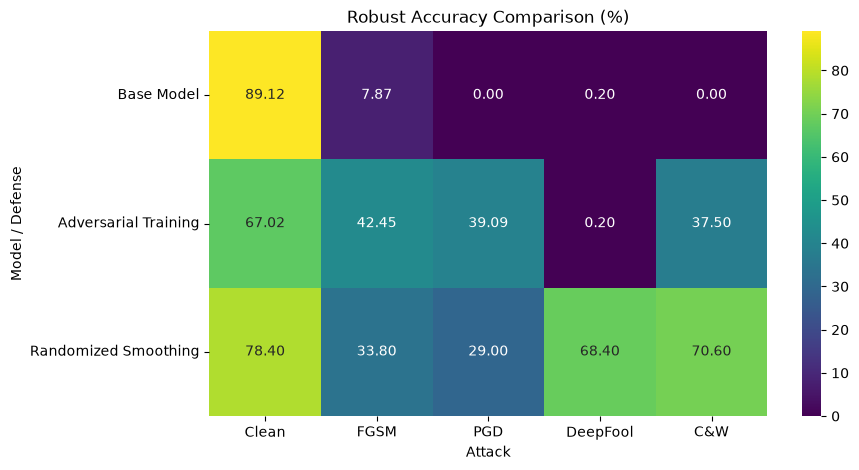

In [120]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    comparison_table_percent,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Robust Accuracy Comparison (%)")
plt.xlabel("Attack")
plt.ylabel("Model / Defense")
plt.show()

## Diffusion Purification

A pretrained DDPM first adds Gaussian noise to weaken the adversarial perturbation and then reconstructs a purified image.

$$
x_t=\sqrt{\bar{\alpha}_t}\,x_{\text{adv}}
+\sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,I)
$$

In [121]:
DIFFPURE_MODEL_NAME = "google/ddpm-cifar10-32"

DIFFPURE_T = 50
DIFFPURE_EVAL_SIZE = 200
DIFFPURE_BATCH_SIZE = 16

DIFFPURE_CLIP_MIN = 0.0
DIFFPURE_CLIP_MAX = 1.0

In [122]:
diffpure_test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=DIFFPURE_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [123]:
ddpm_pipeline = DDPMPipeline.from_pretrained(DIFFPURE_MODEL_NAME)
ddpm_pipeline = ddpm_pipeline.to(device)

ddpm_unet = ddpm_pipeline.unet
ddpm_scheduler = ddpm_pipeline.scheduler

ddpm_unet.eval()

print("Loaded DDPM model:", DIFFPURE_MODEL_NAME)

Loading pipeline components...: 100%|████████████| 2/2 [00:00<00:00, 10.87it/s]


Loaded DDPM model: google/ddpm-cifar10-32


In [124]:
def image_0_1_to_minus1_1(images):
    return images * 2.0 - 1.0

def image_minus1_1_to_0_1(images):
    return (images + 1.0) / 2.0

In [125]:
@torch.no_grad()
def diffpure_purify_images(
    images,
    unet,
    scheduler,
    device,
    t=50
):
    unet.eval()

    images = images.clone().detach().to(device)

    x0 = image_0_1_to_minus1_1(images)

    batch_size = images.size(0)

    timesteps = torch.full(
        (batch_size,),
        t,
        device=device,
        dtype=torch.long
    )

    noise = torch.randn_like(x0)

    xt = scheduler.add_noise(
        original_samples=x0,
        noise=noise,
        timesteps=timesteps
    )

    sample = xt

    for current_t in range(t, -1, -1):
        timestep_tensor = torch.full(
            (batch_size,),
            current_t,
            device=device,
            dtype=torch.long
        )

        noise_pred = unet(
            sample,
            timestep_tensor
        ).sample

        step_output = scheduler.step(
            model_output=noise_pred,
            timestep=current_t,
            sample=sample
        )

        sample = step_output.prev_sample

    purified_images = image_minus1_1_to_0_1(sample)
    purified_images = torch.clamp(purified_images, 0.0, 1.0)

    return purified_images.detach()

In [126]:
sample_images, sample_labels = next(iter(diffpure_test_loader))

sample_images = sample_images[:8].to(device)

purified_images = diffpure_purify_images(
    images=sample_images,
    unet=ddpm_unet,
    scheduler=ddpm_scheduler,
    device=device,
    t=DIFFPURE_T
)

print("Original min/max:", sample_images.min().item(), sample_images.max().item())
print("Purified min/max:", purified_images.min().item(), purified_images.max().item())
print("Purified shape:", purified_images.shape)

assert purified_images.min().item() >= 0.0
assert purified_images.max().item() <= 1.0

Original min/max: 0.0 1.0
Purified min/max: 0.0 1.0
Purified shape: torch.Size([8, 3, 32, 32])


In [127]:
def show_diffpure_clean_examples(
    images,
    purified_images,
    num_images=8
):
    images = images.detach().cpu()
    purified_images = purified_images.detach().cpu()

    plt.figure(figsize=(2 * num_images, 4))

    for i in range(num_images):
        # Original
        plt.subplot(2, num_images, i + 1)
        img_np = images[i].permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0.0, 1.0)
        plt.imshow(img_np)
        plt.title("Original")
        plt.axis("off")

        # Purified
        plt.subplot(2, num_images, num_images + i + 1)
        pur_np = purified_images[i].permute(1, 2, 0).detach().cpu().numpy()
        pur_np = np.clip(pur_np, 0.0, 1.0)
        plt.imshow(pur_np)
        plt.title("Purified")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

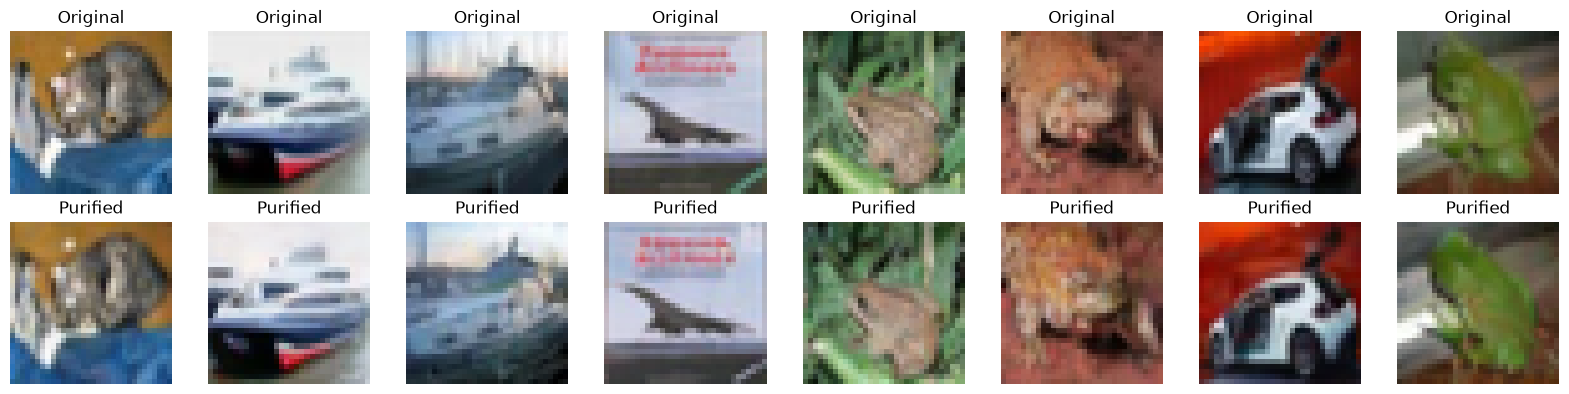

In [128]:
show_diffpure_clean_examples(
    images=sample_images,
    purified_images=purified_images,
    num_images=8
)

In [129]:
def evaluate_diffpure_clean(
    classifier,
    loader,
    unet,
    scheduler,
    device,
    t,
    max_samples=200
):
    classifier.eval()
    unet.eval()

    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        remaining = max_samples - total_samples

        if remaining <= 0:
            break

        images = images[:remaining]
        labels = labels[:remaining]

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        purified_images = diffpure_purify_images(
            images,
            unet,
            scheduler,
            device,
            t
        )

        with torch.no_grad():
            logits = classifier(purified_images)
            preds = logits.argmax(dim=1)

        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        print(f"DiffPure clean | Processed {total_samples}/{max_samples} samples")

    accuracy = total_correct / total_samples

    print(f"DiffPure clean accuracy: {accuracy:.4f}")

    return accuracy

In [130]:
diffpure_clean_acc = evaluate_diffpure_clean(
    classifier=model,
    loader=diffpure_test_loader,
    unet=ddpm_unet,
    scheduler=ddpm_scheduler,
    device=device,
    t=DIFFPURE_T,
    max_samples=DIFFPURE_EVAL_SIZE
)

DiffPure clean | Processed 16/200 samples
DiffPure clean | Processed 32/200 samples
DiffPure clean | Processed 48/200 samples
DiffPure clean | Processed 64/200 samples
DiffPure clean | Processed 80/200 samples
DiffPure clean | Processed 96/200 samples
DiffPure clean | Processed 112/200 samples
DiffPure clean | Processed 128/200 samples
DiffPure clean | Processed 144/200 samples
DiffPure clean | Processed 160/200 samples
DiffPure clean | Processed 176/200 samples
DiffPure clean | Processed 192/200 samples
DiffPure clean | Processed 200/200 samples
DiffPure clean accuracy: 0.8600


In [131]:
def compare_diffpure_inference_time(
    classifier,
    loader,
    unet,
    scheduler,
    device,
    t,
    max_samples=200
):
    classifier.eval()
    unet.eval()

    def synchronize():
        if device.type == "cuda":
            torch.cuda.synchronize()

    warmup_images, _ = next(iter(loader))
    warmup_images = warmup_images[:1].to(
        device,
        non_blocking=True
    )

    with torch.no_grad():
        _ = classifier(warmup_images)

        warmup_purified = diffpure_purify_images(
            images=warmup_images,
            unet=unet,
            scheduler=scheduler,
            device=device,
            t=t
        )

        _ = classifier(warmup_purified)

    synchronize()

    evaluation_batches = []
    collected_samples = 0

    for images, _ in loader:
        remaining = max_samples - collected_samples

        if remaining <= 0:
            break

        images = images[:remaining].to(
            device,
            non_blocking=True
        )

        evaluation_batches.append(images)
        collected_samples += images.size(0)

    if collected_samples == 0:
        raise RuntimeError(
            "No samples were available for inference timing."
        )

    synchronize()
    baseline_start = time.perf_counter()

    with torch.no_grad():
        for images in evaluation_batches:
            _ = classifier(images)

    synchronize()
    baseline_total_time = time.perf_counter() - baseline_start
    
    synchronize()
    diffpure_start = time.perf_counter()

    with torch.no_grad():
        for images in evaluation_batches:
            purified_images = diffpure_purify_images(
                images=images,
                unet=unet,
                scheduler=scheduler,
                device=device,
                t=t
            )

            _ = classifier(purified_images)

    synchronize()
    diffpure_total_time = time.perf_counter() - diffpure_start
    

    baseline_time_per_image = (
        baseline_total_time / collected_samples
    )

    diffpure_time_per_image = (
        diffpure_total_time / collected_samples
    )

    slowdown_factor = (
        diffpure_time_per_image
        / baseline_time_per_image
    )

    additional_time_per_image = (
        diffpure_time_per_image
        - baseline_time_per_image
    )

    timing_results = {
        "num_samples": collected_samples,
        "baseline_total_seconds": baseline_total_time,
        "diffpure_total_seconds": diffpure_total_time,
        "baseline_seconds_per_image": baseline_time_per_image,
        "diffpure_seconds_per_image": diffpure_time_per_image,
        "additional_seconds_per_image": additional_time_per_image,
        "slowdown_factor": slowdown_factor
    }

    print(
        f"Samples: {collected_samples}\n"
        f"Baseline total time: "
        f"{baseline_total_time:.4f} s\n"
        f"DiffPure total time: "
        f"{diffpure_total_time:.4f} s\n"
        f"Baseline time per image: "
        f"{baseline_time_per_image:.6f} s\n"
        f"DiffPure time per image: "
        f"{diffpure_time_per_image:.6f} s\n"
        f"Additional time per image: "
        f"{additional_time_per_image:.6f} s\n"
        f"DiffPure slowdown: "
        f"{slowdown_factor:.2f}x"
    )

    return timing_results

In [132]:
diffpure_timing_results = compare_diffpure_inference_time(
    classifier=model,
    loader=diffpure_test_loader,
    unet=ddpm_unet,
    scheduler=ddpm_scheduler,
    device=device,
    t=DIFFPURE_T,
    max_samples=DIFFPURE_EVAL_SIZE
)

diffpure_timing_results

Samples: 200
Baseline total time: 0.0262 s
DiffPure total time: 60.0879 s
Baseline time per image: 0.000131 s
DiffPure time per image: 0.300439 s
Additional time per image: 0.300308 s
DiffPure slowdown: 2293.54x


{'num_samples': 200,
 'baseline_total_seconds': 0.026198691994068213,
 'diffpure_total_seconds': 60.087866751004185,
 'baseline_seconds_per_image': 0.00013099345997034107,
 'diffpure_seconds_per_image': 0.3004393337550209,
 'additional_seconds_per_image': 0.30030834029505055,
 'slowdown_factor': 2293.544531330381}

In [133]:
def evaluate_attack_with_diffpure(
    classifier,
    loader,
    attack_name,
    criterion,
    unet,
    scheduler,
    device,
    t,
    max_samples=200
):
    classifier.eval()
    unet.eval()

    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        remaining = max_samples - total_samples

        if remaining <= 0:
            break

        images = images[:remaining]
        labels = labels[:remaining]

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if attack_name == "FGSM":
            adv_images = fgsm_attack(
                classifier,
                images,
                labels,
                COMPARE_FGSM_EPSILON,
                criterion,
                device
            )

        elif attack_name == "PGD":
            adv_images = pgd_attack(
                classifier,
                images,
                labels,
                COMPARE_PGD_EPSILON,
                COMPARE_PGD_ALPHA,
                COMPARE_PGD_STEPS,
                criterion,
                device,
                COMPARE_PGD_RANDOM_START
            )

        elif attack_name == "DeepFool":
            adv_images_list = []

            for i in range(images.size(0)):
                image = images[i]
                label = labels[i]

                with torch.no_grad():
                    clean_logits = classifier(image.unsqueeze(0))
                    clean_pred = clean_logits.argmax(dim=1).item()

                if clean_pred != label.item():
                    adv_images_list.append(image.detach().cpu())
                    continue

                adv_image, perturbation, initial_pred, final_pred, num_iter, success = deepfool_attack_single_image(
                    classifier,
                    image,
                    device,
                    DEEPFOOL_NUM_CLASSES,
                    DEEPFOOL_MAX_ITER,
                    DEEPFOOL_OVERSHOOT
                )

                adv_images_list.append(adv_image.detach().cpu())

            adv_images = torch.stack(adv_images_list).to(device)

        elif attack_name == "C&W":
            with torch.no_grad():
                clean_logits = classifier(images)
                clean_preds = clean_logits.argmax(dim=1)

            initially_correct_mask = clean_preds == labels

            adv_images = images.clone().detach()

            if initially_correct_mask.sum().item() > 0:
                images_to_attack = images[initially_correct_mask]
                labels_to_attack = labels[initially_correct_mask]

                cw_adv_images, success, best_l2, final_preds = cw_attack(
                    classifier,
                    images_to_attack,
                    labels_to_attack,
                    CW_C,
                    CW_KAPPA,
                    CW_STEPS,
                    CW_LR,
                    device
                )

                adv_images[initially_correct_mask] = cw_adv_images.detach()

        else:
            raise ValueError(f"Unknown attack name: {attack_name}")

        purified_images = diffpure_purify_images(
            adv_images,
            unet,
            scheduler,
            device,
            t
        )

        with torch.no_grad():
            logits = classifier(purified_images)
            preds = logits.argmax(dim=1)

        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

        print(f"{attack_name} + DiffPure | Processed {total_samples}/{max_samples} samples")

    accuracy = total_correct / total_samples

    print(f"{attack_name} + DiffPure accuracy: {accuracy:.4f}")

    return accuracy

In [134]:
def evaluate_diffpure_against_attacks(
    classifier,
    model_name,
    test_loader,
    criterion,
    unet,
    scheduler,
    device,
    t,
    max_samples=200
):
    print(f"\n==============================")
    print(f"Evaluating DiffPure: {model_name}")
    print(f"t = {t}")
    print(f"==============================")

    results = {}

    # Clean
    clean_acc = evaluate_diffpure_clean(
        classifier=classifier,
        loader=test_loader,
        unet=unet,
        scheduler=scheduler,
        device=device,
        t=t,
        max_samples=max_samples
    )
    results["Clean"] = clean_acc

    # FGSM
    results["FGSM"] = evaluate_attack_with_diffpure(
        classifier=classifier,
        loader=test_loader,
        attack_name="FGSM",
        criterion=criterion,
        unet=unet,
        scheduler=scheduler,
        device=device,
        t=t,
        max_samples=max_samples
    )

    # PGD
    results["PGD"] = evaluate_attack_with_diffpure(
        classifier=classifier,
        loader=test_loader,
        attack_name="PGD",
        criterion=criterion,
        unet=unet,
        scheduler=scheduler,
        device=device,
        t=t,
        max_samples=max_samples
    )

    # DeepFool
    results["DeepFool"] = evaluate_attack_with_diffpure(
        classifier=classifier,
        loader=test_loader,
        attack_name="DeepFool",
        criterion=criterion,
        unet=unet,
        scheduler=scheduler,
        device=device,
        t=t,
        max_samples=max_samples
    )

    # C&W
    results["C&W"] = evaluate_attack_with_diffpure(
        classifier=classifier,
        loader=test_loader,
        attack_name="C&W",
        criterion=criterion,
        unet=unet,
        scheduler=scheduler,
        device=device,
        t=t,
        max_samples=max_samples
    )

    return results

In [135]:
diffpure_results = evaluate_diffpure_against_attacks(
    classifier=model,
    model_name="Diffusion Purification",
    test_loader=diffpure_test_loader,
    criterion=criterion,
    unet=ddpm_unet,
    scheduler=ddpm_scheduler,
    device=device,
    t=DIFFPURE_T,
    max_samples=DIFFPURE_EVAL_SIZE
)

diffpure_results


Evaluating DiffPure: Diffusion Purification
t = 50
DiffPure clean | Processed 16/200 samples
DiffPure clean | Processed 32/200 samples
DiffPure clean | Processed 48/200 samples
DiffPure clean | Processed 64/200 samples
DiffPure clean | Processed 80/200 samples
DiffPure clean | Processed 96/200 samples
DiffPure clean | Processed 112/200 samples
DiffPure clean | Processed 128/200 samples
DiffPure clean | Processed 144/200 samples
DiffPure clean | Processed 160/200 samples
DiffPure clean | Processed 176/200 samples
DiffPure clean | Processed 192/200 samples
DiffPure clean | Processed 200/200 samples
DiffPure clean accuracy: 0.8900
FGSM + DiffPure | Processed 16/200 samples
FGSM + DiffPure | Processed 32/200 samples
FGSM + DiffPure | Processed 48/200 samples
FGSM + DiffPure | Processed 64/200 samples
FGSM + DiffPure | Processed 80/200 samples
FGSM + DiffPure | Processed 96/200 samples
FGSM + DiffPure | Processed 112/200 samples
FGSM + DiffPure | Processed 128/200 samples
FGSM + DiffPure |

{'Clean': 0.89, 'FGSM': 0.625, 'PGD': 0.725, 'DeepFool': 0.845, 'C&W': 0.865}

In [136]:
comparison_table = pd.DataFrame(
    {
        "Base Model": base_model_results,
        "Adversarial Training": adv_model_results,
        "Randomized Smoothing": smooth_model_results,
        "Diffusion Purification": diffpure_results
    }
).T

comparison_table_percent = (comparison_table * 100).round(2)

comparison_table_percent

,Clean,FGSM,PGD,DeepFool,C&W
Base Model,89.12,7.87,0.00,0.2,0.0
Adversarial Training,67.02,42.45,39.09,0.2,37.5
Randomized Smoothing,78.40,33.80,29.00,68.4,70.6
Diffusion Purification,89.00,62.50,72.50,84.5,86.5


## Final Defense Comparison

The clean and robust accuracies of all defense methods are summarized and visualized as a heatmap.

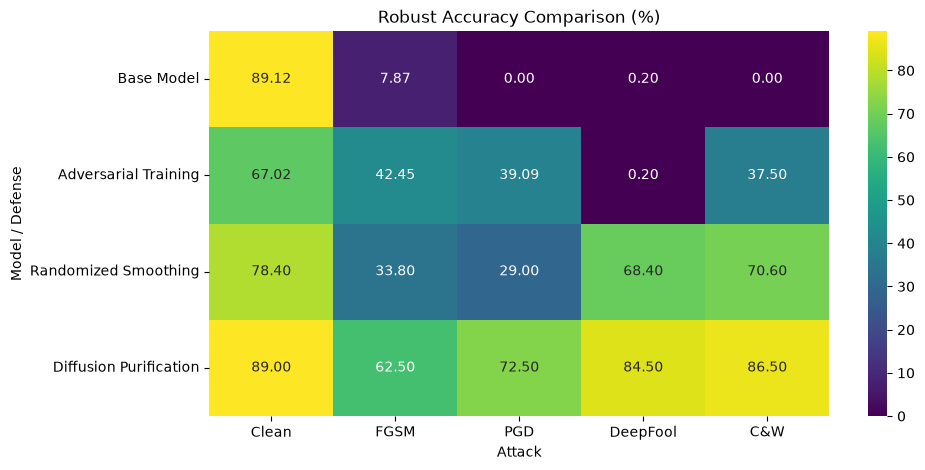

In [137]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    comparison_table_percent,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Robust Accuracy Comparison (%)")
plt.xlabel("Attack")
plt.ylabel("Model / Defense")
plt.show()